## __Phase 3: Modeling__

### __Import packages__

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.experiments.experiment_01 import * 
from scripts.visualization.map_vessel_routes_v2 import * 

### __Load forward results__

In [34]:
# To get below results -> PHMM needs to be runned
df_forward_results = pd.read_pickle("../scripts/test_scripts/alignments_df.pkl")
df_forward_results.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match
0,1,"(205717000, 3)","(205717000, 3)",-16.374425,-0.043319,-0.028879,True
1,2,"(205717000, 3)","(205717000, 3)",-17.393414,-0.046014,-0.030676,True
2,3,"(205717000, 3)","(205717000, 3)",-15.896357,-0.042054,-0.028036,True
3,4,"(205717000, 3)","(205717000, 3)",-15.770054,-0.041720,-0.027813,True
4,1,"(205717000, 7)","(205717000, 7)",-11.115426,-0.055856,-0.037238,True


In [35]:
df_AIS = pd.read_pickle("../scripts/test_scripts/AIS_sample_no_RF_5000.pkl") 
df_AIS_stats = pd.read_pickle("../scripts/test_scripts/statistics_sample_5000.pkl")  
df_train_set = pd.read_pickle("../scripts/test_scripts/train_data_sample_5000.pkl") 

df_AIS.head(5)

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [99]:
df_train_set["ID"].nunique()

5000

In [36]:
counts = (
    df_AIS
    .groupby('ID')       
    .size()                    
    .reset_index(name='count') 
)
forward_with_count = df_forward_results.merge(
    counts,
    left_on='AIS_track_id',
    right_on='ID',
    how='left'   
)

forward_score = forward_with_count["forward_score"]
len_AIS_seq = forward_with_count["count"]
forward_with_count["normalized_forward_score_exp0.9"] = forward_score / (len_AIS_seq**0.9)

df_forward_results_v2 = forward_with_count[['RF_signal_id', 'RF_track_id', 'AIS_track_id', 'forward_score', 'normalized_forward_score', 'is_true_match', 'normalized_forward_score_exp0.9']].copy()
df_forward_results_v2.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,normalized_forward_score_exp0.9
0,1,"(205717000, 3)","(205717000, 3)",-16.374425,-0.043319,True,-0.078419
1,2,"(205717000, 3)","(205717000, 3)",-17.393414,-0.046014,True,-0.083299
2,3,"(205717000, 3)","(205717000, 3)",-15.896357,-0.042054,True,-0.076130
3,4,"(205717000, 3)","(205717000, 3)",-15.770054,-0.041720,True,-0.075525
4,1,"(205717000, 7)","(205717000, 7)",-11.115426,-0.055856,True,-0.094833


### __Summary statistics of forward results__

In [37]:
# Calculate the average number of AIS tracks linked to each RF track 
AIS_tracks_per_RF_signal = df_forward_results_v2.groupby(["RF_signal_id", "RF_track_id"])["AIS_track_id"].nunique()
average_AIS_matches_per_RF_signal = AIS_tracks_per_RF_signal.mean()
print(f"Average number of AIS tracks per RF track: {average_AIS_matches_per_RF_signal:.2f}")

Average number of AIS tracks per RF track: 2.64


### __Results without exponent (0.9)__

In [38]:
def get_best_alignments(df, score_col):
    idx = df.groupby(['RF_signal_id', 'RF_track_id'])[score_col].idxmax()
    return df.loc[idx].reset_index(drop=True)[["RF_signal_id", "RF_track_id", "AIS_track_id", "is_true_match", score_col]]

In [39]:
df_best_norm = get_best_alignments(df_forward_results_v2, "normalized_forward_score")
df_best_norm.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score
0,1,"(205717000, 3)","(205717000, 3)",True,-0.043319
1,1,"(205717000, 7)","(205717000, 7)",True,-0.055856
2,1,"(205717000, 82)","(205717000, 82)",True,-0.036290
3,1,"(209017000, 19)","(209017000, 19)",True,-0.988168
4,1,"(209017000, 23)","(209017000, 23)",True,-0.188957


#### __Precision Score__

In [40]:
def calculate_precision(df_best):
    TP = df_best["is_true_match"].sum()
    FP = (~df_best["is_true_match"]).sum()
    precision = TP / (TP + FP) 
    return (f"The precision score is: {precision:.4f}")

In [41]:
calculate_precision(df_best_norm)

'The precision score is: 0.8923'

#### __Experiment 1__

##### Difference in distance and time between correct and incorrect (chosen) matches

In [42]:
def compute_time_dist_diff(df_best, df_train, suffix=""):
    # Make RF dataframe
    df_RF = df_train[df_train["RF"].notna()].copy()
    df_RF = df_RF[["ID", "RF_Timestamp", "RF"]]
    df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1

    # Merge RF with best alignments 
    df_merged = df_best.merge(df_RF.rename({"ID": "RF_track_id"}, axis=1), on=["RF_signal_id", "RF_track_id"], how="left")

    # Make AIS dataframe
    df_AIS = df_train[df_train["AIS"].notna()].copy()
    df_AIS_grouped = df_AIS.groupby("ID")
    
    if suffix != "":
        suffix = f"_{suffix}"

    # Function
    def compute_diffs(row):
        seq = df_AIS_grouped.get_group(row["AIS_track_id"])
        AIS_time, AIS_coords = min(
            zip(seq["AIS_Timestamp"], seq["AIS"]), 
            key=lambda x: abs(x[0] - row["RF_Timestamp"]).total_seconds())
            
        time_diff = abs((row["RF_Timestamp"] - AIS_time).total_seconds())
        distance_diff = haversine(row["RF"], AIS_coords)
            
        return pd.Series({
            f"AIS_Timestamp{suffix}": AIS_time,
            f"AIS{suffix}": AIS_coords,
            f"time_diff{suffix}": time_diff, 
            f"distance_diff{suffix}": distance_diff
            })
        
    cols = [
        f"AIS_Timestamp{suffix}", 
        f"AIS{suffix}", 
        f"time_diff{suffix}", 
        f"distance_diff{suffix}"
    ]
        
    df_merged[cols] = df_merged.apply(compute_diffs, axis=1)
    return df_merged

In [43]:
def boxplot_time_dist_diff(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots of time_diff and distance_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    time_correct = df_correct['time_diff']
    time_chosen = df_chosen['time_diff']
    dist_correct = df_correct['distance_diff']
    dist_chosen = df_chosen['distance_diff']

    data_time = [time_correct, time_chosen]
    data_dist = [dist_correct, dist_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        time_shouldbe = df_shouldbe['time_diff']
        dist_shouldbe = df_shouldbe['distance_diff']
        data_time.append(time_shouldbe)
        data_dist.append(dist_shouldbe)
        labels.append('Incorrect (should-be)')

    mean_time = [x.mean() for x in data_time]
    med_time = [x.median() for x in data_time]
    mean_dist = [x.mean() for x in data_dist]
    med_dist = [x.median() for x in data_dist]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Time difference boxplot
    ax1.boxplot(data_time, tick_labels=labels, showfliers=False, showmeans=True)
    ax1.set_title('Time difference (without outliers)')
    ax1.set_ylabel('Seconds')
    for i, (mean, median) in enumerate(zip(mean_time, med_time), start=1):
        ax1.text(i + 0.17, mean, f"mean {mean:.1f}", color='green', ha='left', va='center')
        ax1.text(i - 0.17, median, f"median {median:.1f}", color='darkorange', ha='right', va='center')

    # Distance difference boxplot
    ax2.boxplot(data_dist, tick_labels=labels, showfliers=False, showmeans=True)
    ax2.set_title('Distance difference (without outliers)')
    ax2.set_ylabel('Kilometers')
    
    for i, (mean, median) in enumerate(zip(mean_dist, med_dist), start=1):
        ax2.text(i + 0.17, mean, f"mean {mean:.1f}", color='green', ha='left', va='center')
        ax2.text(i - 0.17, median, f"median {median:.1f}", color='darkorange', ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [44]:
def histplot_time_dist_error(df_chosen, df_shouldbe):
    """
    Maakt histogrammen van de fout in tijd en afstand
    tussen incorrect gekozen match en de correcte (should-be).
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["time_error"] = df_merged["time_diff_chosen"] - df_merged["time_diff_shouldbe"]
    df_merged["distance_error"] = df_merged["distance_diff_chosen"] - df_merged["distance_diff_shouldbe"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Time error
    sns.histplot(df_merged["time_error"], bins=50, kde=True, ax=ax1)
    ax1.set_title("Histogram of time error (chosen − should-be)")
    ax1.set_xlabel("Tijd-fout (seconden)")
    ax1.set_ylabel("Frequentie")

    # Distance error
    sns.histplot(df_merged["distance_error"], bins=50, kde=True, ax=ax2)
    ax2.set_title("Histogram of distance error (chosen − should-be)")
    ax2.set_xlabel("Afstand-fout (kilometers)")
    ax2.set_ylabel("Frequentie")

    plt.tight_layout()
    plt.show()

In [45]:
correct = df_best_norm[df_best_norm["is_true_match"]]
incorrect = df_best_norm[~df_best_norm["is_true_match"]]

df_correct = compute_time_dist_diff(correct, df_train_set)
df_incorrect_chosen = compute_time_dist_diff(incorrect, df_train_set)
df_incorrect_shouldbe_raw = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect_chosen[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))
df_incorrect_shouldbe = compute_time_dist_diff(df_incorrect_shouldbe_raw, df_train_set)

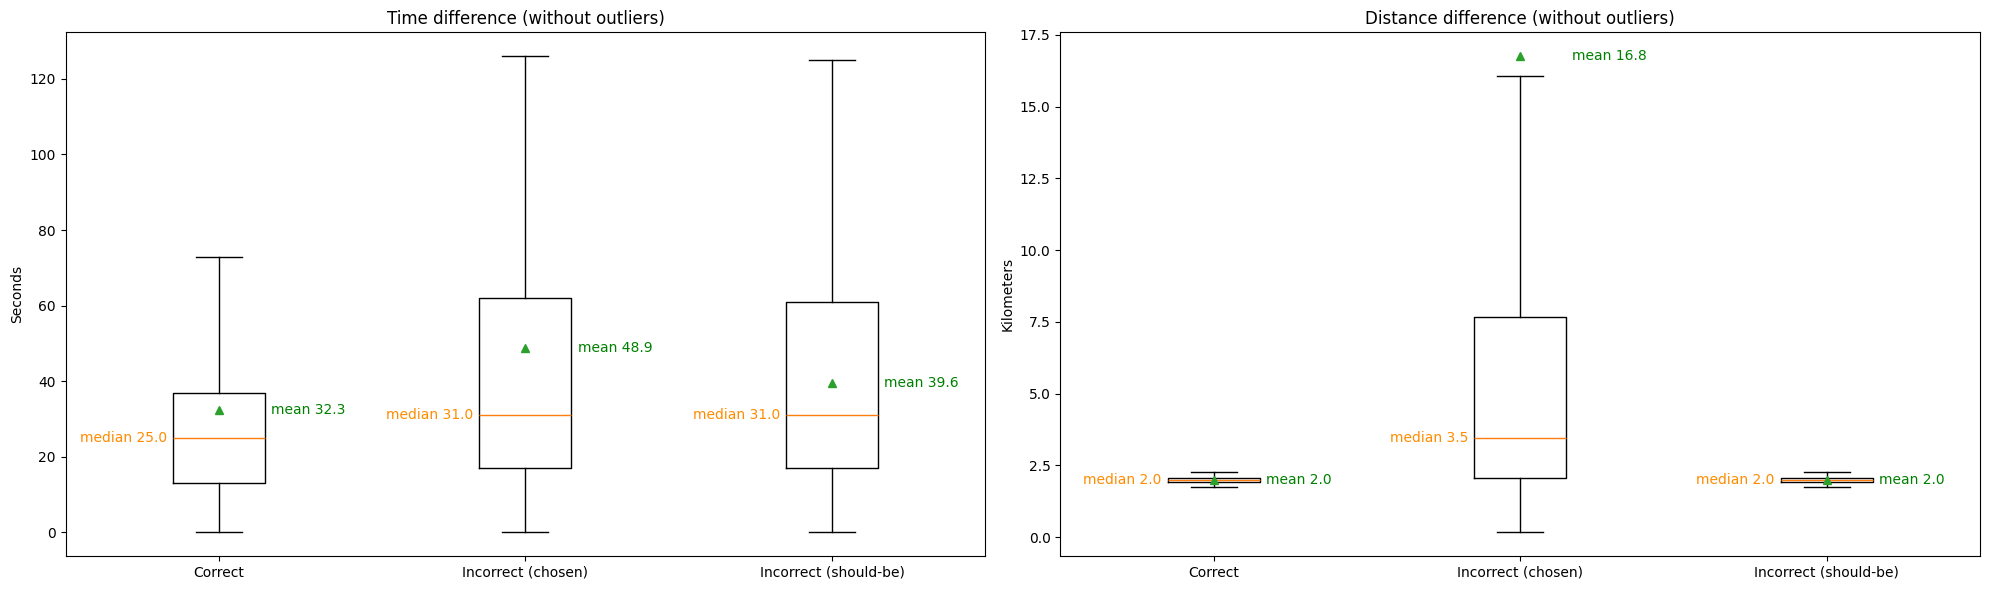

In [46]:
boxplot_time_dist_diff(df_correct, df_incorrect_chosen, df_incorrect_shouldbe)

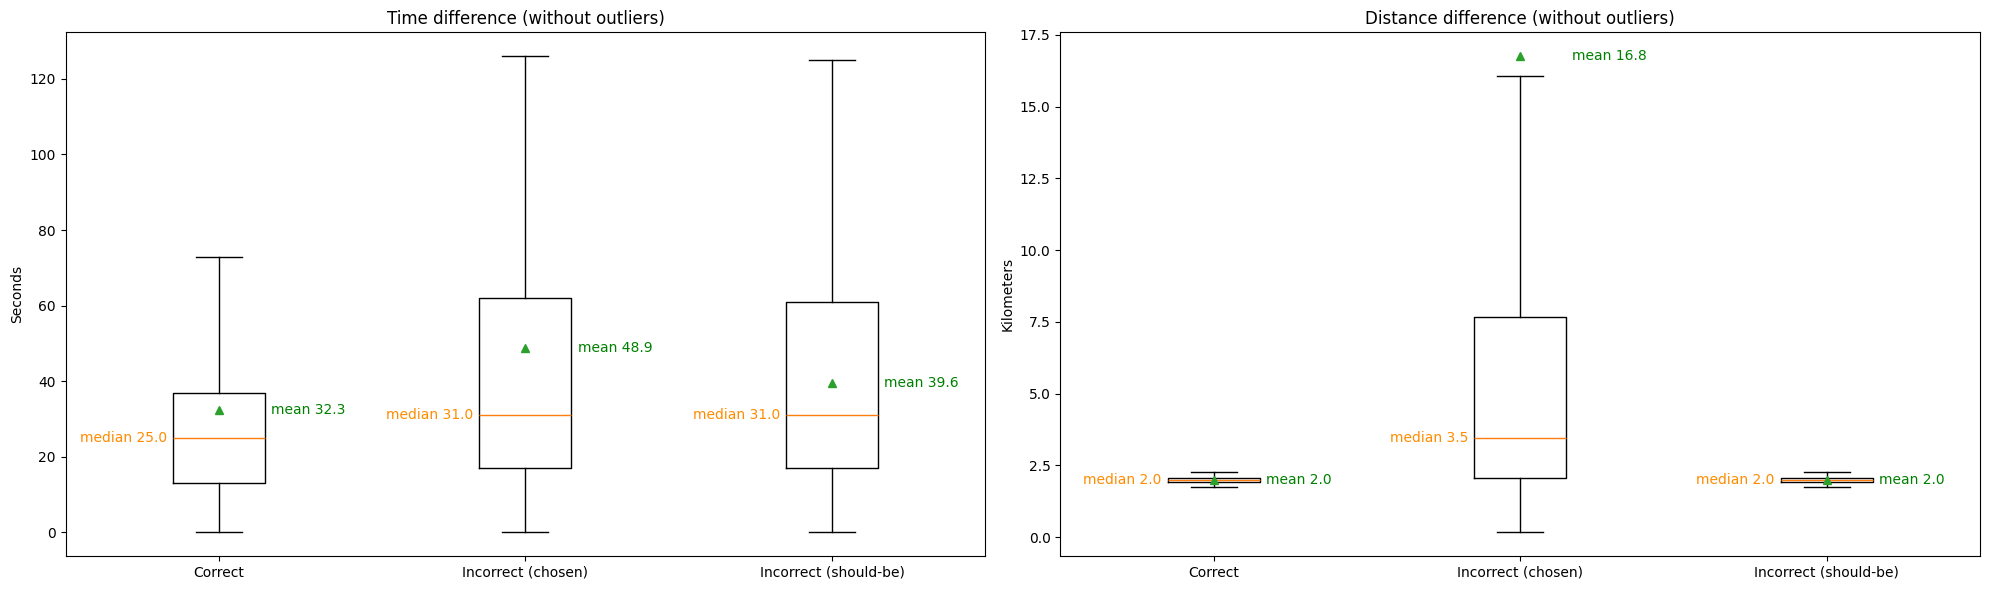

In [47]:
boxplot_time_dist_diff(df_correct, df_incorrect_chosen, df_incorrect_shouldbe)

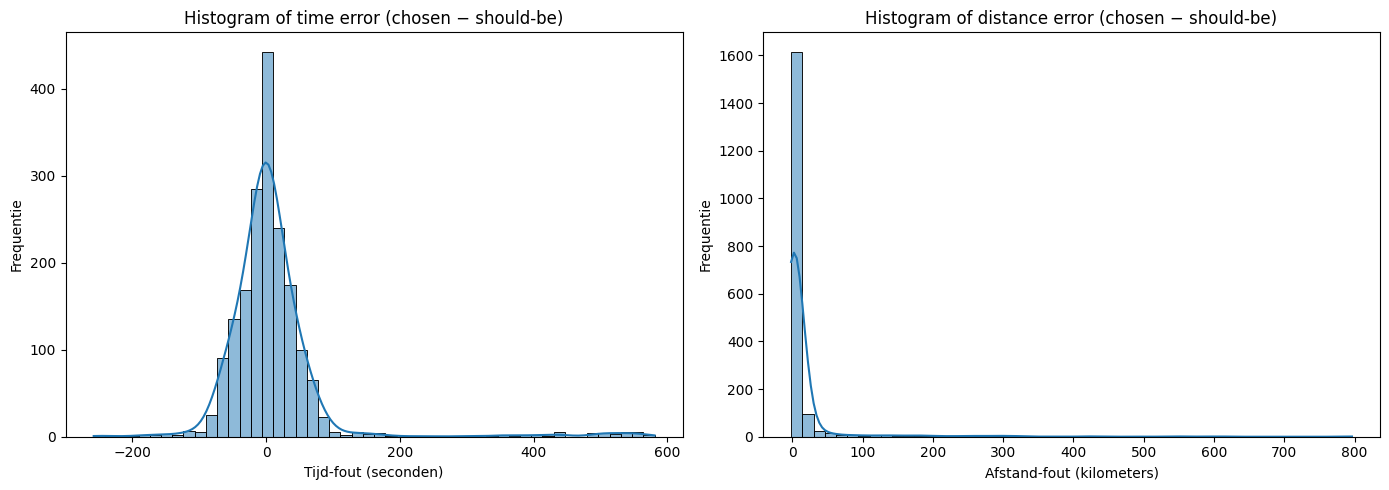

In [48]:
histplot_time_dist_error(df_incorrect_chosen, df_incorrect_shouldbe)

Conclusie: 

Time difference error: 

- De overgrote meerderheid zit binnen +- 2 minuten tussen gekozen en juiste match
- Er zijn enkele uitschieters waarbij de gekozen match veel later valt dan de juiste match

Distance difference error: 

- In bijna alle gevallen ligt de gekozen match qua afstand verder weg dan de juiste
- In een klein aantal gevallen wijken de gekozen en juiste match extreem af (niet perse erg toch?)

#### __Experiment 2__

In [49]:
def compute_mean_intra_time(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    return df.merge(df_AIS_stats[["ID", "mean_intra_time_diff"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [50]:
def boxplot_mean_intra_time(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of mean_intra_time_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    intra_correct = df_correct['mean_intra_time_diff']
    intra_chosen  = df_chosen['mean_intra_time_diff']

    data = [intra_correct, intra_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        intra_shouldbe = df_shouldbe['mean_intra_time_diff']
        data.append(intra_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
    ax.set_title('Mean intra-time difference: Correct vs Incorrect')
    ax.set_ylabel('Seconds')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [51]:
def histplot_intra_time_error(df_chosen, df_shouldbe):
    """
    Plots a histogram of the error in mean intra-time between
    incorrectly chosen and should-be AIS tracks.
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["intra_time_error"] = (df_merged["mean_intra_time_diff_chosen"] - df_merged["mean_intra_time_diff_shouldbe"])

    plt.figure(figsize=(8, 6))
    sns.histplot(df_merged["intra_time_error"], bins=50, kde=True)
    plt.title("Histogram of mean intra-time error (chosen − should-be)")
    plt.xlabel("Mean intra-time error (seconds)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [52]:
df_correct_stats = compute_mean_intra_time(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_mean_intra_time(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_mean_intra_time(df_incorrect_shouldbe, df_AIS_stats)

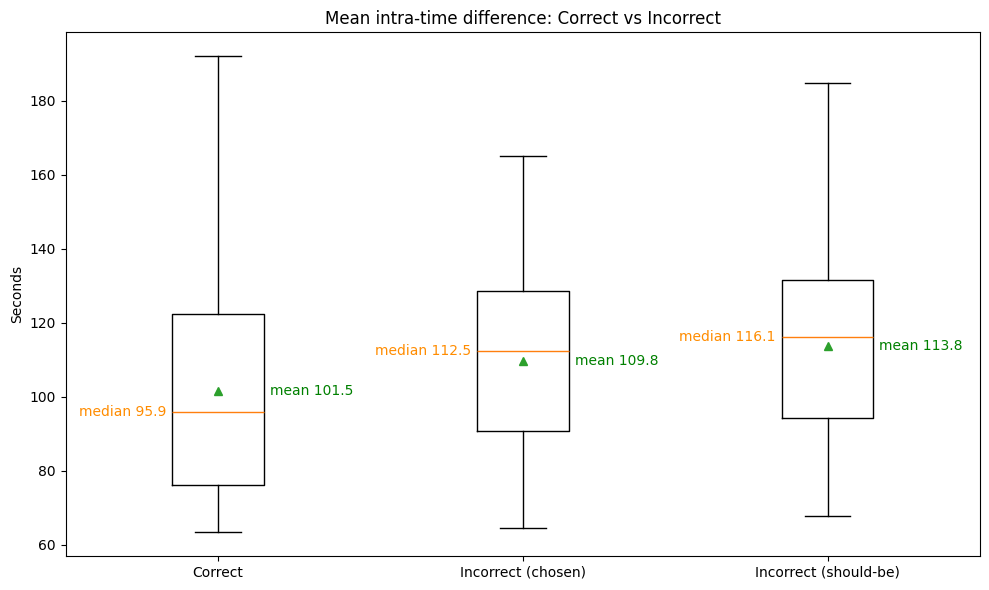

In [53]:
boxplot_mean_intra_time(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

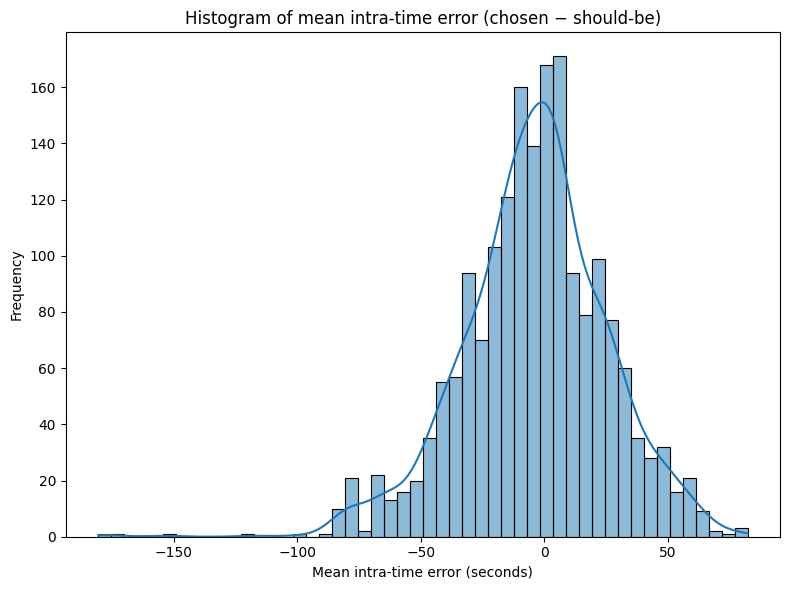

In [54]:
histplot_intra_time_error(df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

Conclusie:

De gekozen AIS track heeft een lagere gemiddelde intra-time dan de juiste (verdeling is scheef naar links). 

#### __Experiment 3__

In [55]:
def compute_track_behavior(df, df_AIS, stationary_threshold = 5):
    """
    Adds per-track behavior statistics to the given dataframe
    """
    df_AIS = df_AIS.copy()
    df_AIS["is_stationary"] = df_AIS["speed_kph"] < stationary_threshold
    track_behavior_stats = (
        df_AIS
        .groupby("ID")
        .agg(
            std_speed_kph = ("speed_kph", "std"),
            stationary_ratio = ("is_stationary", "mean")
        )
        .reset_index()
        .set_index("ID")
    )
    return df.merge(track_behavior_stats, left_on = "AIS_track_id", right_on = "ID", how = "left")

In [56]:
def boxplot_track_behavior(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots for track-level behavior metrics:
    - std_speed_kph (speed variability)
    - stationary_ratio (proportion of time under threshold)
    """
    speed_correct = df_correct['std_speed_kph']
    speed_chosen  = df_chosen['std_speed_kph']
    station_correct = df_correct['stationary_ratio']
    station_chosen  = df_chosen['stationary_ratio']

    speed_data = [speed_correct, speed_chosen]
    stationary_data = [station_correct, station_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        speed_shouldbe = df_shouldbe['std_speed_kph']
        station_shouldbe = df_shouldbe['stationary_ratio']
        speed_data.append(speed_shouldbe)
        stationary_data.append(station_shouldbe)
        labels.append('Incorrect (should-be)')

    speed_means = [x.mean() for x in speed_data]
    speed_medians = [x.median() for x in speed_data]
    station_means = [x.mean() for x in stationary_data]
    station_medians = [x.median() for x in stationary_data]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    ax1.boxplot(speed_data, tick_labels=labels, showfliers=False, showmeans=True)
    ax1.set_title("Speed Variation (std_speed_kph)")
    ax1.set_ylabel("Standard Deviation of Speed (km/h)")

    for i, (m, med) in enumerate(zip(speed_means, speed_medians), start=1):
        ax1.text(i + 0.17, m,   f"mean {m:.2f}", color="green", ha='left', va='center')
        ax1.text(i - 0.17, med, f"median {med:.2f}", color="darkorange", ha='right', va='center')

    ax2.boxplot(stationary_data, tick_labels=labels, showfliers=False, showmeans=True)
    ax2.set_title("Stationary Behavior (stationary_ratio)")
    ax2.set_ylabel("Proportion of Time Stationary (< 5 km/h)")

    for i, (m, med) in enumerate(zip(station_means, station_medians), start=1):
        ax2.text(i + 0.17, m,   f"mean {m:.2f}", color="green", ha='left', va='center')
        ax2.text(i - 0.17, med, f"median {med:.2f}", color="darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()


In [57]:
def histplot_track_behavior_errors(df_chosen, df_shouldbe):
    """
    Plots histograms of the errors between incorrectly chosen and should-be AIS tracks
    for:
    - std_speed_kph (speed variability)
    - stationary_ratio (proportion of time under threshold)
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["speed_std_error"] = (df_merged["std_speed_kph_chosen"] - df_merged["std_speed_kph_shouldbe"])
    df_merged["stationary_error"] = (df_merged["stationary_ratio_chosen"] - df_merged["stationary_ratio_shouldbe"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df_merged["speed_std_error"], bins=50, kde=True, ax=axes[0])
    axes[0].set_title("Speed std error (chosen − should-be)")
    axes[0].set_xlabel("Speed std error (km/h)")
    axes[0].set_ylabel("Frequency")

    sns.histplot(df_merged["stationary_error"], bins=50, kde=True, ax=axes[1])
    axes[1].set_title("Stationary ratio error (chosen − should-be)")
    axes[1].set_xlabel("Stationary ratio error")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


In [58]:
df_correct_behavior = compute_track_behavior(df_correct, df_AIS)
df_incorrect_chosen_behavior = compute_track_behavior(df_incorrect_chosen, df_AIS)
df_incorrect_shouldbe_behavior = compute_track_behavior(df_incorrect_shouldbe, df_AIS)

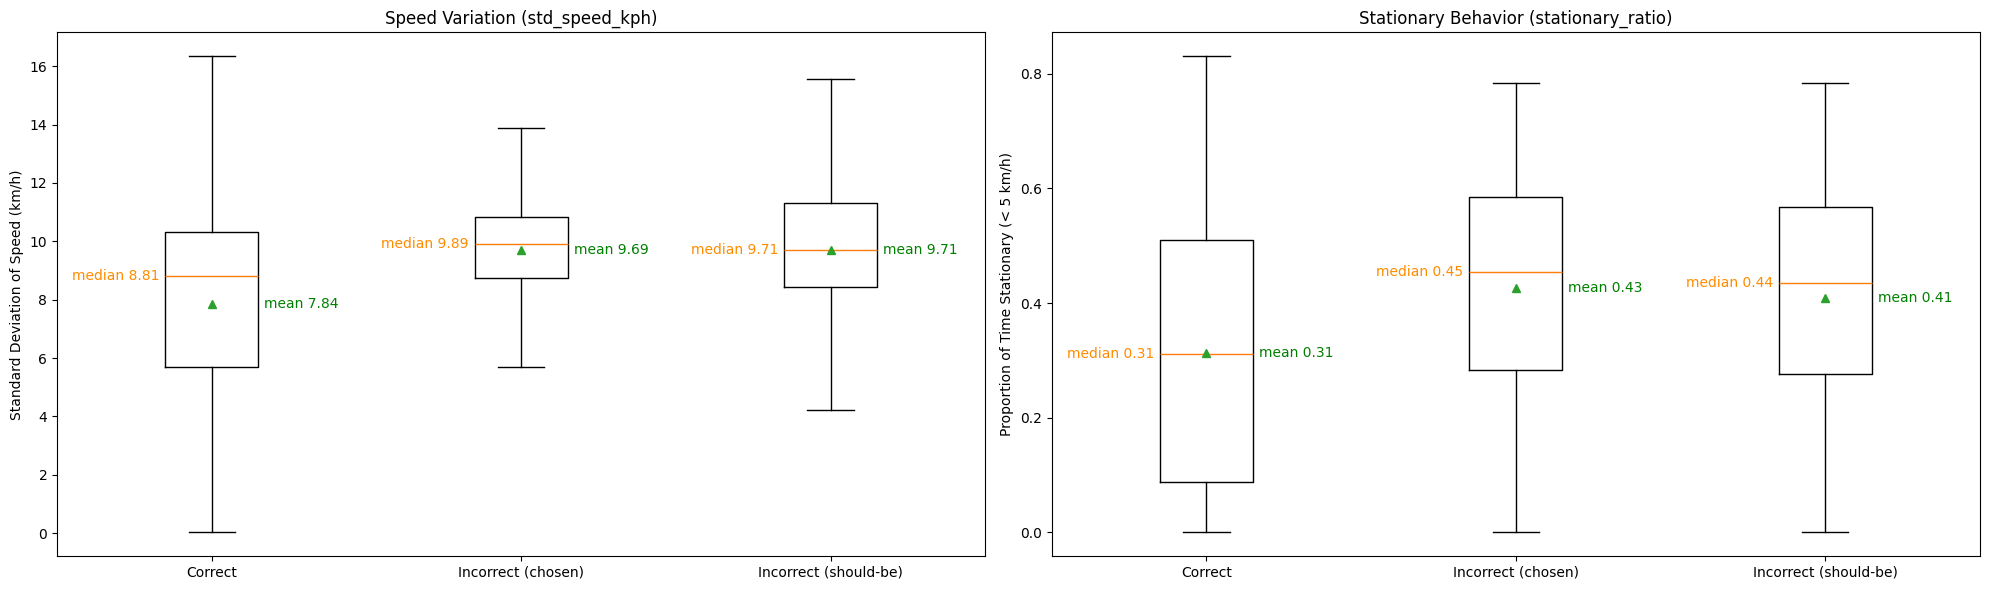

In [59]:
boxplot_track_behavior(df_correct_behavior, df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior)

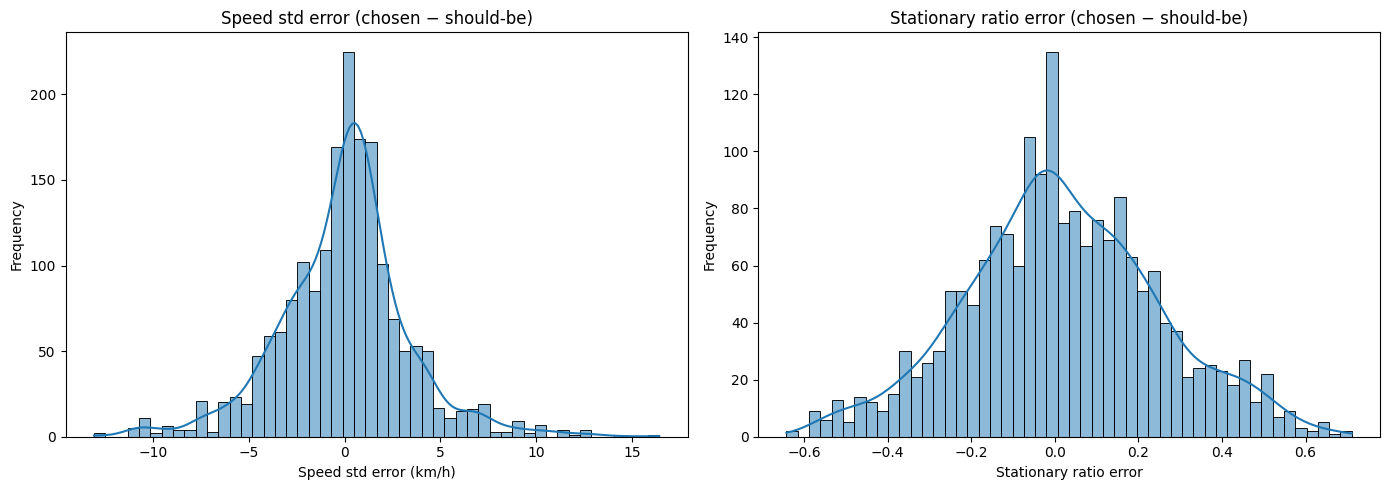

In [60]:
histplot_track_behavior_errors(df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior)

#### __Some other experiments__

In [61]:
def compute_track_length(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    return df.merge(df_AIS_stats[["ID", "#points"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [62]:
def boxplot_track_length(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of track_length for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    length_correct = df_correct['#points']
    length_chosen  = df_chosen['#points']

    data = [length_correct, length_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        length_shouldbe = df_shouldbe['#points']
        data.append(length_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
    ax.set_title('Number of AIS points per track: Correct vs Incorrect')
    ax.set_ylabel('Number of points')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [63]:
df_correct_stats = compute_track_length(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_track_length(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_track_length(df_incorrect_shouldbe, df_AIS_stats)

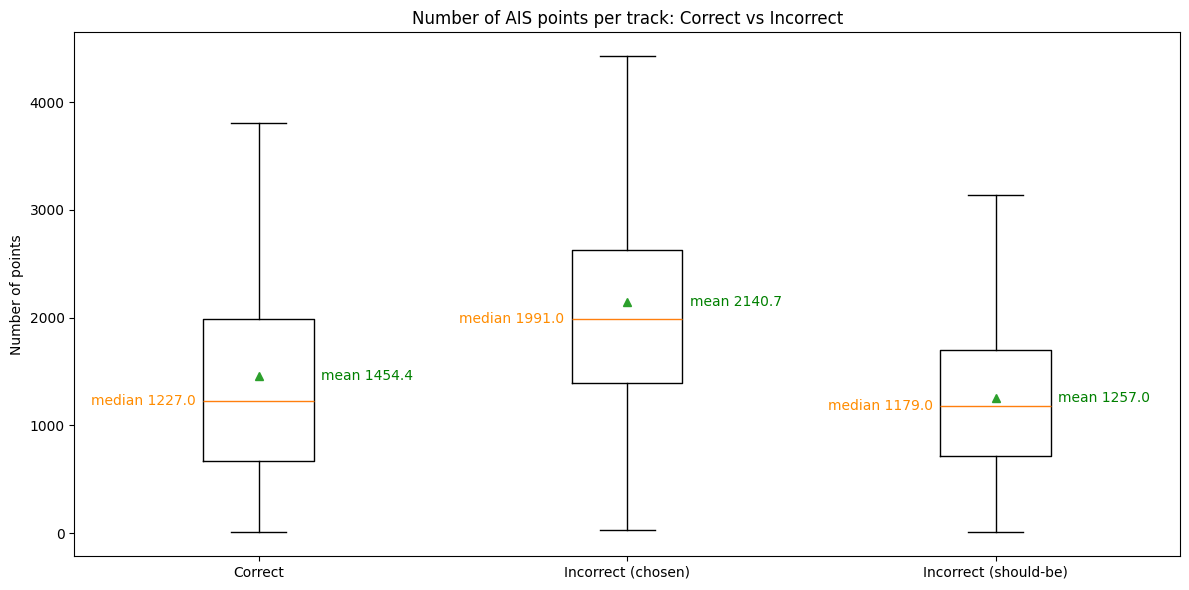

In [64]:
boxplot_track_length(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

In [65]:
def compute_sampling_rate(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    df_AIS_stats = df_AIS_stats.copy()
    df_AIS_stats["sampling_rate"] = df_AIS_stats["#points"]/df_AIS_stats["track_duration"]
    return df.merge(df_AIS_stats[["ID", "sampling_rate"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [66]:
def boxplot_sampling_rate(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of the sampling rate (AIS points per track) for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    rate_correct = df_correct['sampling_rate']
    rate_chosen = df_chosen['sampling_rate']

    data = [rate_correct, rate_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        rate_shouldbe = df_shouldbe['sampling_rate']
        data.append(rate_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
    ax.set_title('Sampling Rate: Correct vs Incorrect Matches')
    ax.set_ylabel('AIS points per unit time (sampling rate)')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.2f}", color="green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.2f}", color="darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [67]:
df_correct_stats = compute_sampling_rate(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_sampling_rate(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_sampling_rate(df_incorrect_shouldbe, df_AIS_stats)

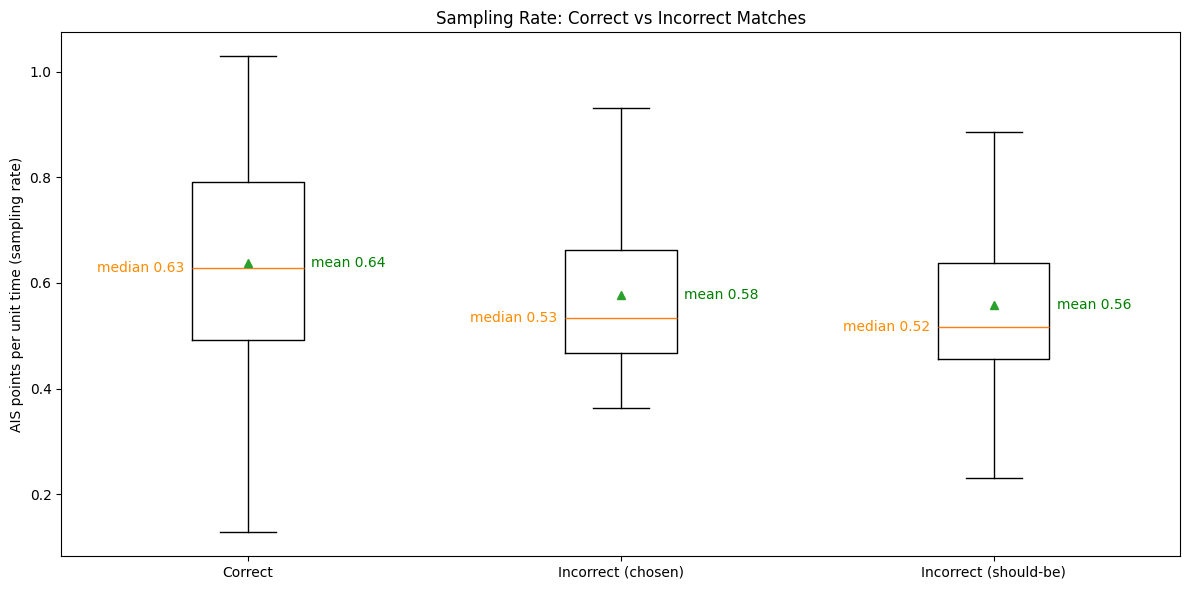

In [68]:
boxplot_sampling_rate(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

### __Results with exponent (0.9)__

In [69]:
df_best_norm_exp_0_9 = get_best_alignments(df_forward_results_v2, "normalized_forward_score_exp0.9")
df_best_norm_exp_0_9.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_exp0.9
0,1,"(205717000, 3)","(205717000, 3)",True,-0.078419
1,1,"(205717000, 7)","(205717000, 7)",True,-0.094833
2,1,"(205717000, 82)","(205717000, 82)",True,-0.069920
3,1,"(209017000, 19)","(209017000, 19)",True,-1.200441
4,1,"(209017000, 23)","(209017000, 23)",True,-0.268049


#### __Precision Score__

In [70]:
calculate_precision(df_best_norm_exp_0_9)

'The precision score is: 0.9156'

#### __Experiment 1__

In [71]:
correct = df_best_norm_exp_0_9[df_best_norm_exp_0_9["is_true_match"]]
incorrect = df_best_norm_exp_0_9[~df_best_norm_exp_0_9["is_true_match"]]

df_correct = compute_time_dist_diff(correct, df_train_set)
df_incorrect_chosen = compute_time_dist_diff(incorrect, df_train_set)
df_incorrect_shouldbe_raw = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect_chosen[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))
df_incorrect_shouldbe = compute_time_dist_diff(df_incorrect_shouldbe_raw, df_train_set)

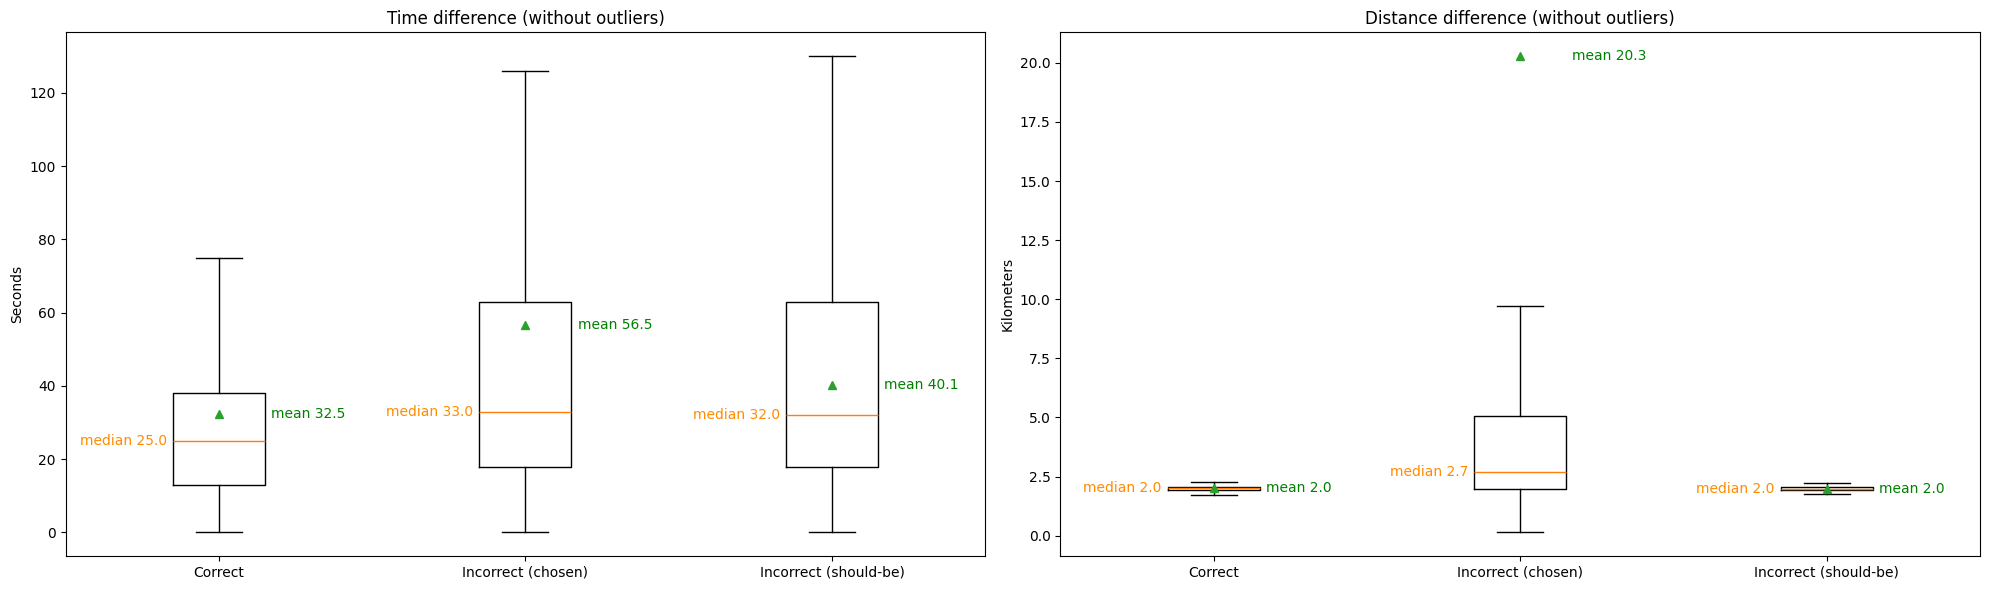

In [72]:
boxplot_time_dist_diff(df_correct, df_incorrect_chosen, df_incorrect_shouldbe)

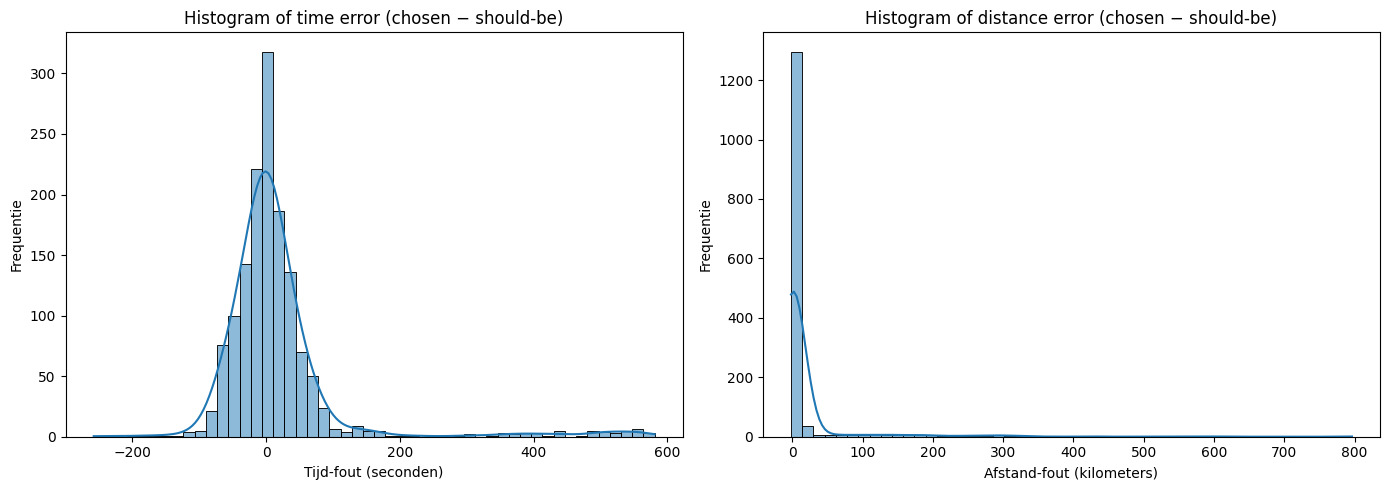

In [73]:
histplot_time_dist_error(df_incorrect_chosen, df_incorrect_shouldbe)

In [74]:
df_incorrect_shouldbe[df_incorrect_shouldbe["AIS_track_id"] == (209087000, 10)]

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff
0,1,"(209087000, 10)","(209087000, 10)",-29.016735,-0.032313,-0.021542,True,2024-01-07 23:08:37,"[29.677950233611714, -94.97021974531077]",2024-01-07 23:08:36,"[29.68233, -94.99186]",1.0,2.146568
1,2,"(209087000, 10)","(209087000, 10)",-30.431288,-0.033888,-0.022592,True,2024-01-08 02:07:00,"[29.6875718287059, -94.97246318967987]",2024-01-08 02:05:36,"[29.68232, -94.99202]",84.0,1.977425
2,3,"(209087000, 10)","(209087000, 10)",-29.040935,-0.032340,-0.021560,True,2024-01-08 05:08:47,"[29.69715677184802, -94.98026919798889]",2024-01-08 05:08:42,"[29.68231, -94.99208]",5.0,2.006756
3,4,"(209087000, 10)","(209087000, 10)",-30.201004,-0.033631,-0.022421,True,2024-01-08 08:26:02,"[29.685405504836147, -94.97315807158326]",2024-01-08 08:26:43,"[29.68234, -94.99206]",41.0,1.857528
4,5,"(209087000, 10)","(209087000, 10)",-30.444482,-0.033903,-0.022602,True,2024-01-08 11:40:10,"[29.698288153117197, -94.98381659136895]",2024-01-08 11:38:43,"[29.68232, -94.99205]",87.0,1.945564
5,6,"(209087000, 10)","(209087000, 10)",-29.075227,-0.032378,-0.021585,True,2024-01-08 15:27:16,"[29.67097798146197, -94.97595046395112]",2024-01-08 15:26:46,"[29.68239, -94.9921]",30.0,2.011095


In [75]:
df_incorrect_chosen[df_incorrect_chosen["AIS_track_id"] == (351567000, 19)]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_exp0.9,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff
0,1,"(209087000, 10)","(351567000, 19)",False,-0.063266,2024-01-07 23:08:37,"[29.677950233611714, -94.97021974531077]",2024-01-07 23:08:06,"[29.68078, -95.00172]",31.0,3.059381
192,2,"(209087000, 10)","(351567000, 19)",False,-0.063740,2024-01-08 02:07:00,"[29.6875718287059, -94.97246318967987]",2024-01-08 02:08:05,"[29.68081, -95.00174]",65.0,2.926458
223,2,"(311008600, 17)","(351567000, 19)",False,-0.064840,2024-01-08 02:07:00,"[29.65288207204314, -94.9658593738429]",2024-01-08 02:08:05,"[29.68081, -95.00174]",65.0,4.654274
331,3,"(209087000, 10)","(351567000, 19)",False,-0.063194,2024-01-08 05:08:47,"[29.69715677184802, -94.98026919798889]",2024-01-08 05:08:05,"[29.68076, -95.00175]",42.0,2.762219
482,4,"(209087000, 10)","(351567000, 19)",False,-0.064116,2024-01-08 08:26:02,"[29.685405504836147, -94.97315807158326]",2024-01-08 08:26:06,"[29.68077, -95.00178]",4.0,2.812621
616,5,"(209087000, 10)","(351567000, 19)",False,-0.063631,2024-01-08 11:40:10,"[29.698288153117197, -94.98381659136895]",2024-01-08 11:41:05,"[29.68082, -95.00176]",55.0,2.603288
744,6,"(209087000, 10)","(351567000, 19)",False,-0.063336,2024-01-08 15:27:16,"[29.67097798146197, -94.97595046395112]",2024-01-08 15:26:05,"[29.68079, -95.00175]",71.0,2.720846


#### __Experiment 2__

In [76]:
df_correct_stats = compute_mean_intra_time(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_mean_intra_time(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_mean_intra_time(df_incorrect_shouldbe, df_AIS_stats)

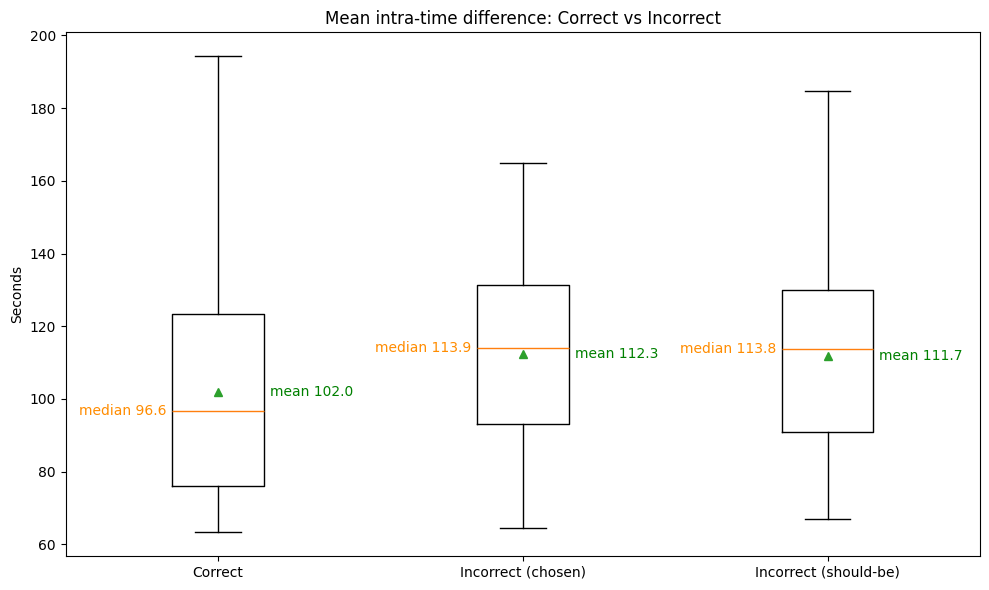

In [77]:
boxplot_mean_intra_time(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

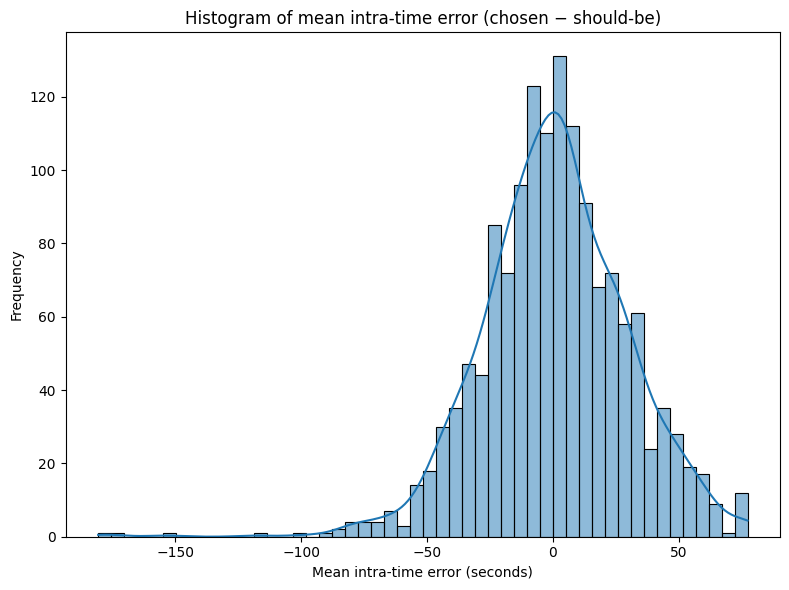

In [78]:
histplot_intra_time_error(df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

In [79]:
df_incorrect_shouldbe_stats[df_incorrect_shouldbe_stats["AIS_track_id"] == (209087000, 10)]

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,ID,mean_intra_time_diff
0,1,"(209087000, 10)","(209087000, 10)",-29.016735,-0.032313,-0.021542,True,2024-01-07 23:08:37,"[29.677950233611714, -94.97021974531077]",2024-01-07 23:08:36,"[29.68233, -94.99186]",1.0,2.146568,"(209087000, 10)",134.707915
1,2,"(209087000, 10)","(209087000, 10)",-30.431288,-0.033888,-0.022592,True,2024-01-08 02:07:00,"[29.6875718287059, -94.97246318967987]",2024-01-08 02:05:36,"[29.68232, -94.99202]",84.0,1.977425,"(209087000, 10)",134.707915
2,3,"(209087000, 10)","(209087000, 10)",-29.040935,-0.032340,-0.021560,True,2024-01-08 05:08:47,"[29.69715677184802, -94.98026919798889]",2024-01-08 05:08:42,"[29.68231, -94.99208]",5.0,2.006756,"(209087000, 10)",134.707915
3,4,"(209087000, 10)","(209087000, 10)",-30.201004,-0.033631,-0.022421,True,2024-01-08 08:26:02,"[29.685405504836147, -94.97315807158326]",2024-01-08 08:26:43,"[29.68234, -94.99206]",41.0,1.857528,"(209087000, 10)",134.707915
4,5,"(209087000, 10)","(209087000, 10)",-30.444482,-0.033903,-0.022602,True,2024-01-08 11:40:10,"[29.698288153117197, -94.98381659136895]",2024-01-08 11:38:43,"[29.68232, -94.99205]",87.0,1.945564,"(209087000, 10)",134.707915
5,6,"(209087000, 10)","(209087000, 10)",-29.075227,-0.032378,-0.021585,True,2024-01-08 15:27:16,"[29.67097798146197, -94.97595046395112]",2024-01-08 15:26:46,"[29.68239, -94.9921]",30.0,2.011095,"(209087000, 10)",134.707915


In [80]:
df_incorrect_chosen_stats[df_incorrect_chosen_stats["AIS_track_id"] == (351567000, 19)]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_exp0.9,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,ID,mean_intra_time_diff
0,1,"(209087000, 10)","(351567000, 19)",False,-0.063266,2024-01-07 23:08:37,"[29.677950233611714, -94.97021974531077]",2024-01-07 23:08:06,"[29.68078, -95.00172]",31.0,3.059381,"(351567000, 19)",112.872321
192,2,"(209087000, 10)","(351567000, 19)",False,-0.063740,2024-01-08 02:07:00,"[29.6875718287059, -94.97246318967987]",2024-01-08 02:08:05,"[29.68081, -95.00174]",65.0,2.926458,"(351567000, 19)",112.872321
223,2,"(311008600, 17)","(351567000, 19)",False,-0.064840,2024-01-08 02:07:00,"[29.65288207204314, -94.9658593738429]",2024-01-08 02:08:05,"[29.68081, -95.00174]",65.0,4.654274,"(351567000, 19)",112.872321
331,3,"(209087000, 10)","(351567000, 19)",False,-0.063194,2024-01-08 05:08:47,"[29.69715677184802, -94.98026919798889]",2024-01-08 05:08:05,"[29.68076, -95.00175]",42.0,2.762219,"(351567000, 19)",112.872321
482,4,"(209087000, 10)","(351567000, 19)",False,-0.064116,2024-01-08 08:26:02,"[29.685405504836147, -94.97315807158326]",2024-01-08 08:26:06,"[29.68077, -95.00178]",4.0,2.812621,"(351567000, 19)",112.872321
616,5,"(209087000, 10)","(351567000, 19)",False,-0.063631,2024-01-08 11:40:10,"[29.698288153117197, -94.98381659136895]",2024-01-08 11:41:05,"[29.68082, -95.00176]",55.0,2.603288,"(351567000, 19)",112.872321
744,6,"(209087000, 10)","(351567000, 19)",False,-0.063336,2024-01-08 15:27:16,"[29.67097798146197, -94.97595046395112]",2024-01-08 15:26:05,"[29.68079, -95.00175]",71.0,2.720846,"(351567000, 19)",112.872321


#### __Experiment 3__

In [81]:
df_correct_behavior = compute_track_behavior(df_correct, df_AIS)
df_incorrect_chosen_behavior = compute_track_behavior(df_incorrect_chosen, df_AIS)
df_incorrect_shouldbe_behavior = compute_track_behavior(df_incorrect_shouldbe, df_AIS)

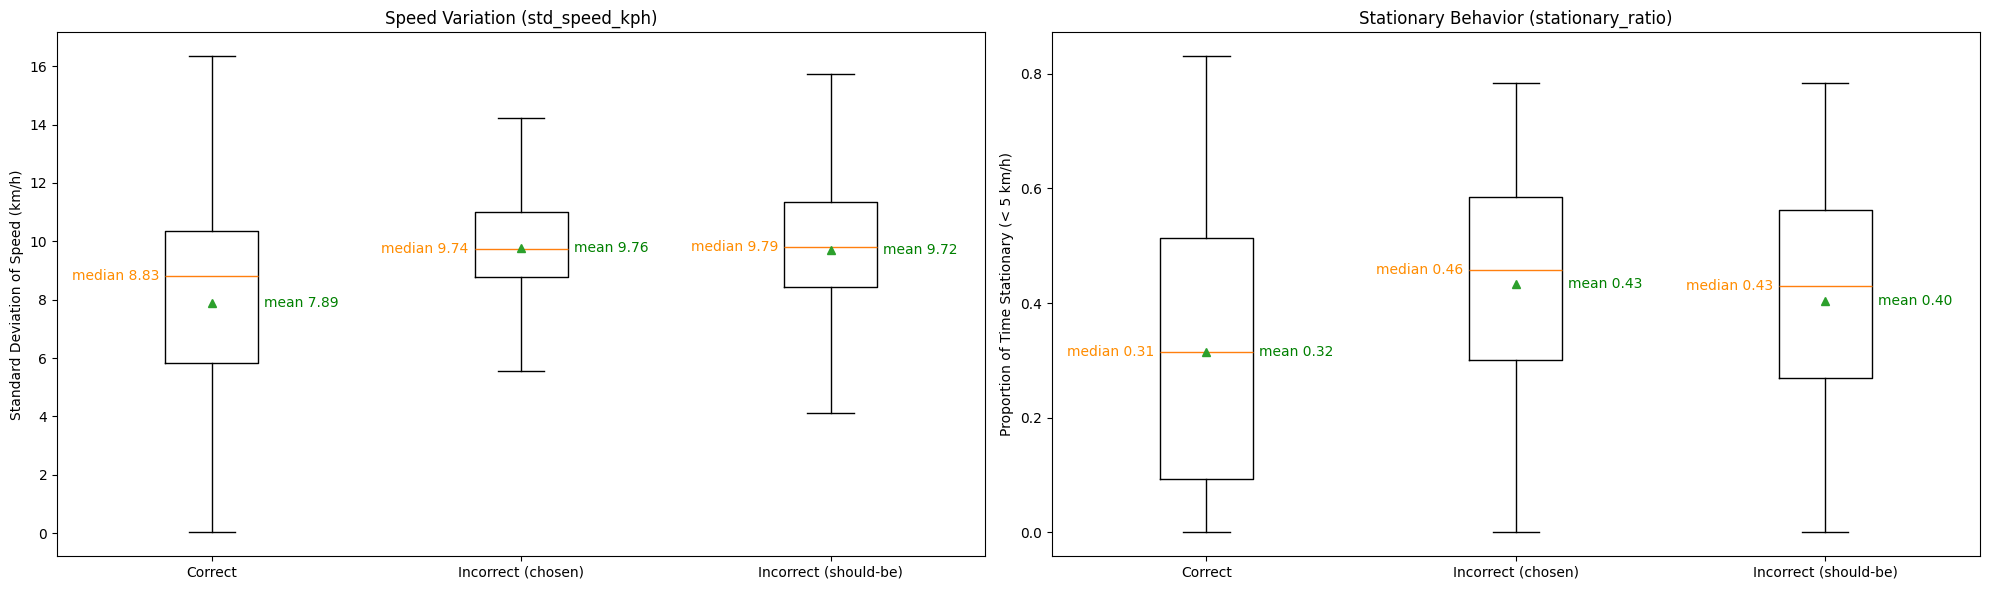

In [82]:
boxplot_track_behavior(df_correct_behavior, df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior,)

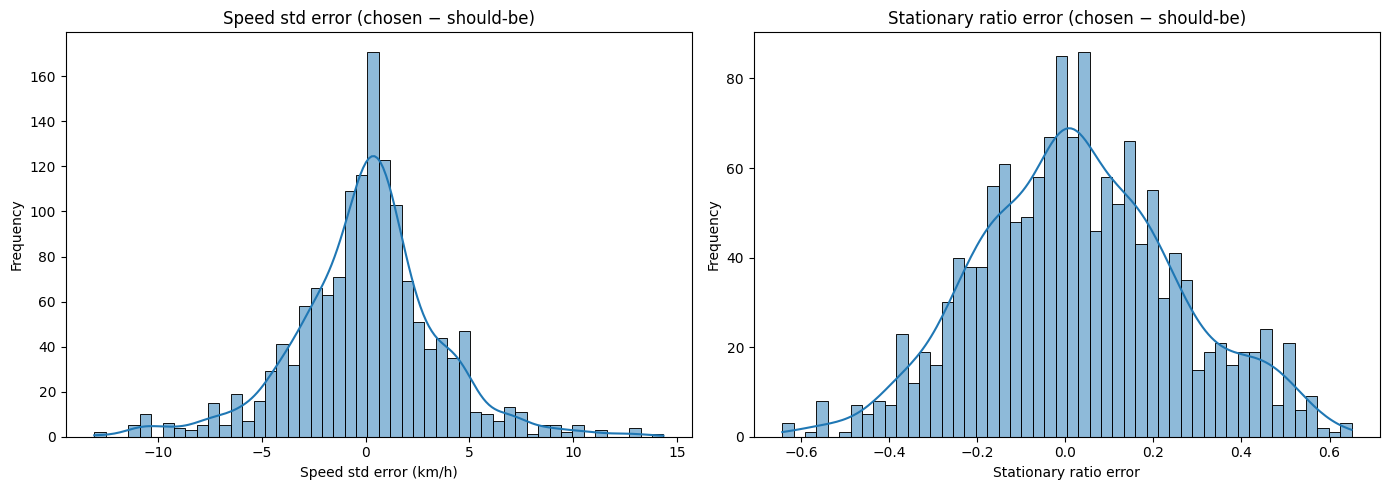

In [83]:
histplot_track_behavior_errors(df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior)

#### __Some other experiments__

In [84]:
df_correct_stats = compute_track_length(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_track_length(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_track_length(df_incorrect_shouldbe, df_AIS_stats)

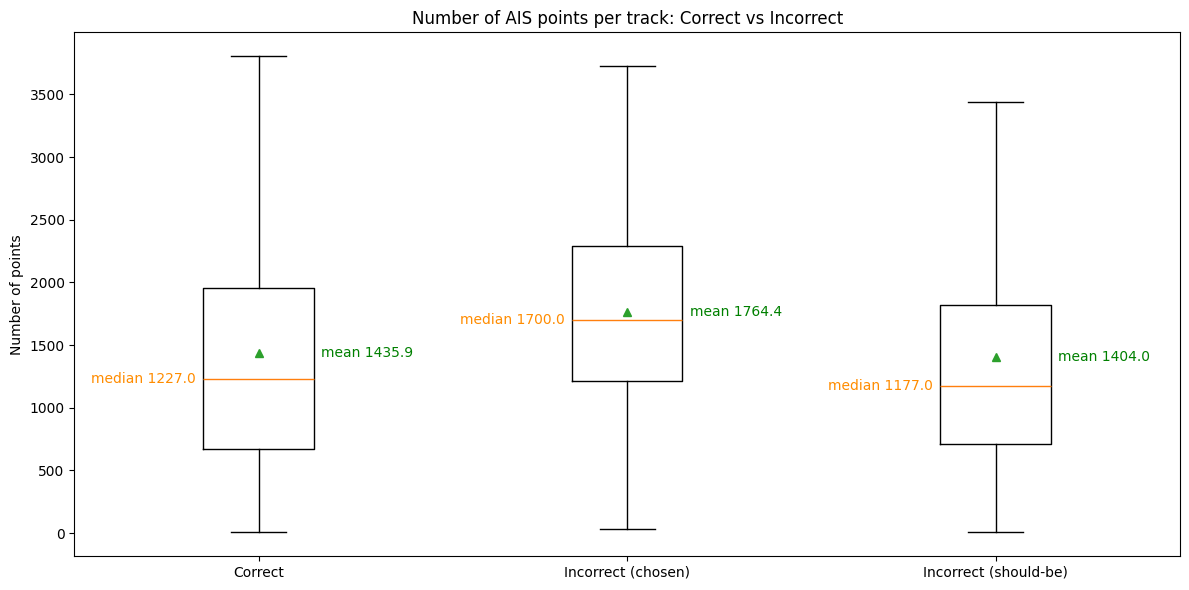

In [85]:
boxplot_track_length(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

In [86]:
df_correct_stats = compute_sampling_rate(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_sampling_rate(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_sampling_rate(df_incorrect_shouldbe, df_AIS_stats)

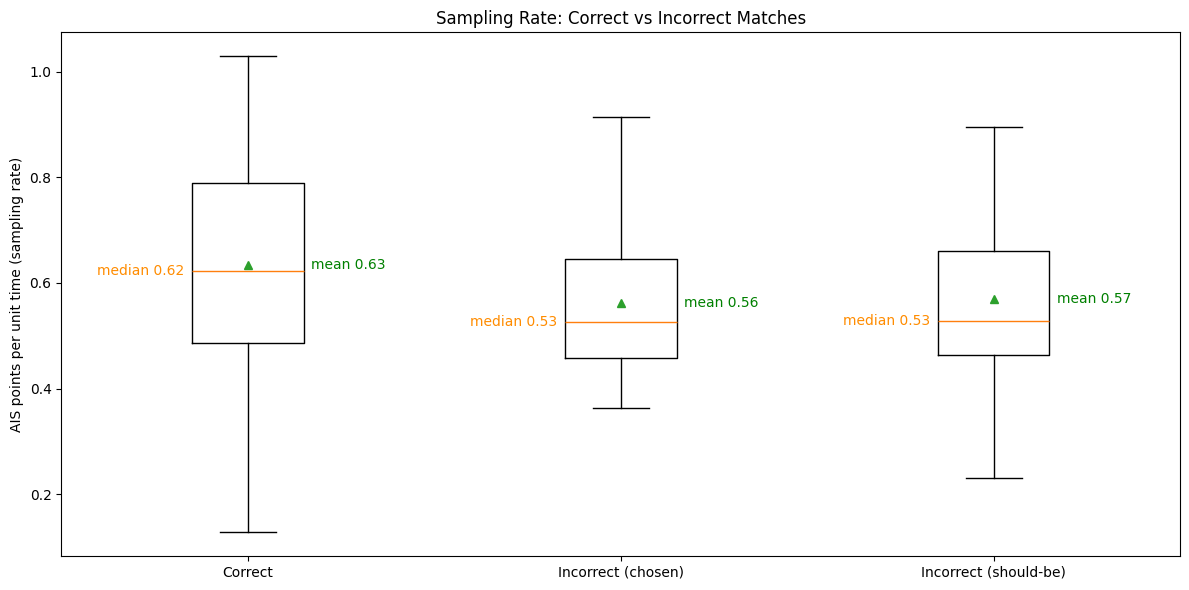

In [87]:
boxplot_sampling_rate(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

Voorbeeld die verkeerd gematcht is Rf signaal 1 van mmsi, track id (209087000, 10) met mmsi, track id (351567000, 19):	
- chosen: 
    - time diff: 31.0
    - dist diff: 3.059381
    - AIS naar RF trans prob: 0.3728
    - intra: 112.872321
    - speed variation:
    - stationary behavior:
- should be: 
    - time diff: 1.0
    - dist diff: 2.146568
    - AIS naar RF trans prob: 0.5395
    - intra: 134.707915
    - speed variation:
    - stationary behavior:

In [88]:
df_best_norm_exp_0_9

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_exp0.9
0,1,"(205717000, 3)","(205717000, 3)",True,-0.078419
1,1,"(205717000, 7)","(205717000, 7)",True,-0.094833
2,1,"(205717000, 82)","(205717000, 82)",True,-0.069920
3,1,"(209017000, 19)","(209017000, 19)",True,-1.200441
4,1,"(209017000, 23)","(209017000, 23)",True,-0.268049
...,...,...,...,...,...
17076,41,"(366904890, 0)","(366904890, 0)",True,-0.064343
17077,41,"(366938770, 0)","(366938770, 0)",True,-0.063304
17078,41,"(366938780, 0)","(366938780, 0)",True,-0.065041
17079,41,"(367121010, 0)","(367121010, 0)",True,-0.064279


In [89]:
df_best_norm_exp_0_9[df_best_norm_exp_0_9["is_true_match"] == False]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_exp0.9
5,1,"(209087000, 10)","(351567000, 19)",False,-0.063266
65,1,"(215228000, 7)","(636017316, 12)",False,-0.064291
71,1,"(215765000, 2)","(636019582, 6)",False,-0.061431
130,1,"(235058697, 2)","(244730000, 5)",False,-0.117922
153,1,"(241821000, 16)","(566846000, 47)",False,-0.068578
...,...,...,...,...,...
17031,35,"(366938780, 0)","(367050160, 2)",False,-0.063053
17035,36,"(309253000, 5)","(477648800, 15)",False,-0.063024
17038,36,"(366904890, 0)","(366906610, 2)",False,-0.063248
17047,37,"(366904890, 0)","(366906610, 2)",False,-0.062931


In [90]:
df_train_set[(df_train_set["ID"] == (209087000, 10)) & (~df_train_set["RF"].isna())]

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
1366,"(209087000, 10)",10,209087000,2024-01-07 23:08:37,NaT,2024-01-07 23:08:37,None,"[29.677950233611714, -94.97021974531077]",RF
1367,"(209087000, 10)",10,209087000,2024-01-08 02:05:36,2024-01-08 02:05:36,2024-01-08 02:07:00,"[29.68232, -94.99202]","[29.6875718287059, -94.97246318967987]",M
1368,"(209087000, 10)",10,209087000,2024-01-08 05:08:47,NaT,2024-01-08 05:08:47,None,"[29.69715677184802, -94.98026919798889]",RF
1369,"(209087000, 10)",10,209087000,2024-01-08 08:26:02,NaT,2024-01-08 08:26:02,None,"[29.685405504836147, -94.97315807158326]",RF
1370,"(209087000, 10)",10,209087000,2024-01-08 11:38:43,2024-01-08 11:38:43,2024-01-08 11:40:10,"[29.68232, -94.99205]","[29.698288153117197, -94.98381659136895]",M
1371,"(209087000, 10)",10,209087000,2024-01-08 15:27:16,NaT,2024-01-08 15:27:16,None,"[29.67097798146197, -94.97595046395112]",RF
1372,"(209087000, 10)",10,209087000,2024-01-08 19:11:03,NaT,2024-01-08 19:11:03,None,"[29.692802884641708, -94.97657186309652]",RF
1373,"(209087000, 10)",10,209087000,2024-01-08 23:08:37,NaT,2024-01-08 23:08:37,None,"[29.527361794154785, -94.89923303940037]",RF
1374,"(209087000, 10)",10,209087000,2024-01-09 02:07:00,NaT,2024-01-09 02:07:00,None,"[29.17842022816227, -94.47768029245181]",RF
1375,"(209087000, 10)",10,209087000,2024-01-09 05:08:47,NaT,2024-01-09 05:08:47,None,"[28.723601852510424, -93.71638574082982]",RF


In [91]:
plot_AIS_and_RF_data(df_AIS, df_train_set, [(209087000, 10), (351567000, 19)]) # kleur punten anders en zoek afstand en tijd voor beide op 

In [92]:
df_train_set

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
382,"(205717000, 3)",3,205717000,2024-01-01 03:40:23,NaT,NaT,None,None,begin
4,"(205717000, 3)",3,205717000,2024-01-01 03:40:24,2024-01-01 03:40:24,NaT,"[46.89339, -125.42151]",None,AIS
5,"(205717000, 3)",3,205717000,2024-01-01 03:44:15,2024-01-01 03:44:15,NaT,"[46.89344, -125.39996]",None,AIS
6,"(205717000, 3)",3,205717000,2024-01-01 03:45:33,2024-01-01 03:45:33,NaT,"[46.8935, -125.39274]",None,AIS
7,"(205717000, 3)",3,205717000,2024-01-01 03:46:39,2024-01-01 03:46:39,NaT,"[46.89348, -125.38572]",None,AIS
...,...,...,...,...,...,...,...,...,...
2189886,"(750000045, 16)",16,750000045,2024-01-10 22:58:19,2024-01-10 22:58:19,NaT,"[16.45501, -66.4437]",None,AIS
2189887,"(750000045, 16)",16,750000045,2024-01-10 23:02:55,2024-01-10 23:02:55,NaT,"[16.44986, -66.4364]",None,AIS
2189888,"(750000045, 16)",16,750000045,2024-01-10 23:04:12,2024-01-10 23:04:12,NaT,"[16.44836, -66.43436]",None,AIS
2189879,"(750000045, 16)",16,750000045,2024-01-10 23:08:37,NaT,2024-01-10 23:08:37,None,"[16.43139716169542, -66.44067859128745]",RF


In [93]:
# Ben hier nu, alles hierboven is goed

In [94]:
# De rest mag straks weg 

In [95]:
15.906163/(500**0.9),15.906163/(300**0.9)

(0.059223275662281354, 0.0937899489274585)

In [96]:
15.906163/(500**1.2),15.906163/(300**1.2)

(0.009179127945377922, 0.016944155287784025)

In [97]:
forward_results["forward_score"].min()

NameError: name 'forward_results' is not defined

In [ ]:
forward_results = forward_with_count.copy()

best_predictions = forward_results.loc[
    forward_results.groupby(["RF_signal_id", "RF_track_id"])["normalized_forward_score_alpha"].idxmax()
]

# TP: a correct match between an RF signal and AIS track
# FP: an incorrect match, the algorithm believes it is a match, but in reality is not
# Precision: TP / (TP + FP)

TP = best_predictions["is_true_match"].sum()
FP = (~best_predictions["is_true_match"]).sum()
precision = TP / (TP + FP) 
print(f"Precision: {precision:.4f}")

Precision: 0.9244


In [ ]:
best_predictions.groupby('is_true_match').agg({'count' : 'mean'})

,count
is_true_match,
False,2363.309337
True,1455.873825


In [ ]:
best_predictions.groupby('is_true_match').agg({'count' : 'mean'})

,count
is_true_match,
False,1773.450039
True,1433.774984


### __Experiment 1__

In [ ]:
df_exp_1_results = process_experiment_one(forward_results, df_train_set)

In [ ]:
df_exp_1_results

,RF_signal_id,RF_track_id,AIS_track_id_pred,norm_forward_pred,norm_viterbi_pred,distance_diff_pred,time_diff_pred,path_pred,AIS_track_id_true,norm_forward_true,norm_viterbi_true,distance_diff_true,time_diff_true,path_true
0,1,"(209087000, 10)","(351567000, 19)",-0.020988,-0.020988,3.059381,31.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(209087000, 10)",-0.021542,-0.021542,2.146568,1.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
1,1,"(210499000, 15)","(368270390, 0)",-0.019512,-0.019512,21.200605,35.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(210499000, 15)",-0.022288,-0.022972,1.971137,65.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
2,1,"(215228000, 7)","(636017316, 12)",-0.020728,-0.021101,1.374904,54.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(215228000, 7)",-0.031009,-0.031245,1.947551,26.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
3,1,"(215765000, 2)","(636019582, 6)",-0.019465,-0.019465,2.048241,23.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(215765000, 2)",-0.020396,-0.020396,2.125579,90.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
4,1,"(235010180, 19)","(477909100, 31)",-0.023561,-0.023561,3.361191,30.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(235010180, 19)",-0.024158,-0.024158,2.018105,27.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1726,22,"(366904910, 0)","(366904890, 0)",-0.017832,-0.017880,6.350517,0.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(366904910, 0)",-0.018216,-0.018293,2.045520,2.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
1727,22,"(636018910, 0)","(373765000, 12)",-0.018747,-0.018755,1.987593,19.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(636018910, 0)",-0.019173,-0.019173,2.018537,54.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
1728,23,"(636022464, 30)","(256524000, 97)",-0.018655,-0.018791,0.318417,63.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(636022464, 30)",-0.018803,-0.018803,2.090215,80.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."
1729,24,"(256524000, 97)","(636022464, 30)",-0.018596,-0.018774,0.410039,26.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS...","(256524000, 97)",-0.018659,-0.018659,1.968972,9.0,"[begin, AIS, AIS, AIS, AIS, AIS, AIS, AIS, AIS..."


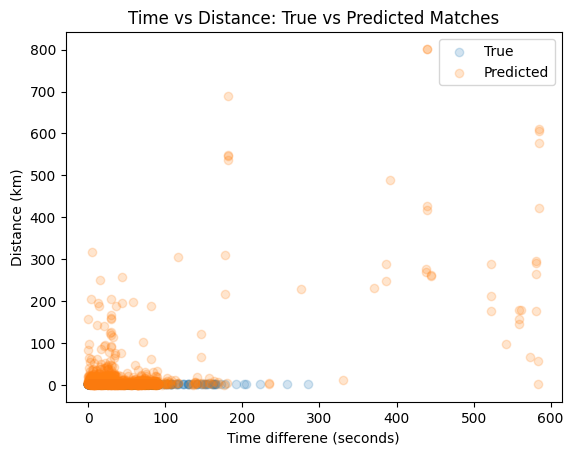

In [ ]:
plt.figure()

# Scatter plot to compare time and distance differences between true and predicted tracks
plt.scatter(df_exp_1_results["time_diff_true"], df_exp_1_results["distance_diff_true"], label="True", alpha=0.2)
plt.scatter(df_exp_1_results["time_diff_pred"], df_exp_1_results["distance_diff_pred"], label="Predicted", alpha=0.2)

plt.xlabel("Time differene (seconds)")
plt.ylabel("Distance (km)")
plt.title("Time vs Distance: True vs Predicted Matches")

plt.legend()
plt.show()

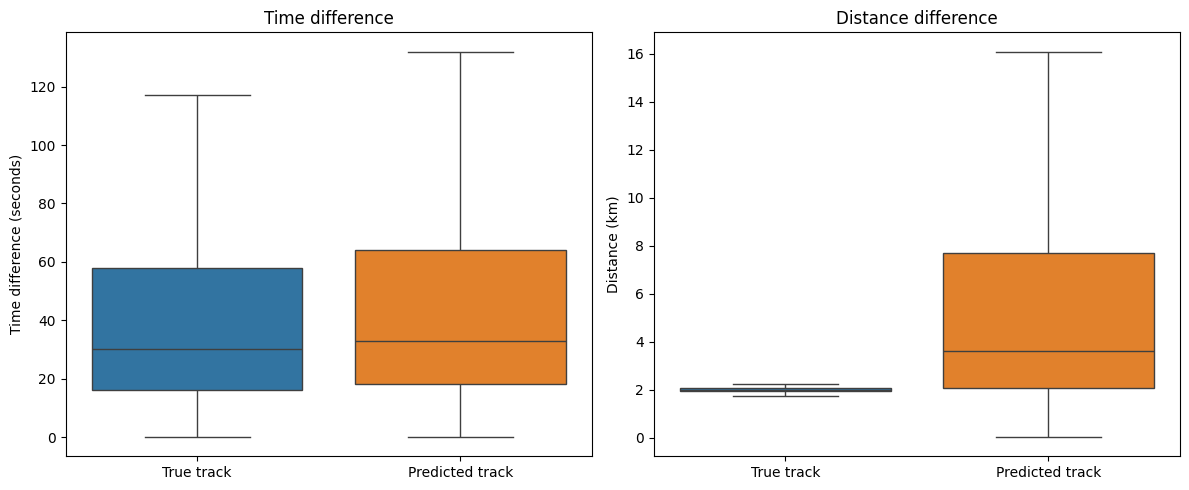

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot 1: time difference
sns.boxplot(
    data=df_exp_1_results[["time_diff_true", "time_diff_pred"]],
    ax=axes[0],
    showfliers=False
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["True track", "Predicted track"])
axes[0].set_ylabel("Time difference (seconds)")
axes[0].set_title("Time difference")

# Boxplot 2: distance difference
sns.boxplot(
    data=df_exp_1_results[["distance_diff_true", "distance_diff_pred"]],
    ax=axes[1],
    showfliers=False
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["True track", "Predicted track"])
axes[1].set_ylabel("Distance (km)")
axes[1].set_title("Distance difference")

plt.tight_layout()
plt.show()

# Conclusion: other factors (than distance and time) influence the selection of the predicted AIS track over the true AIS track

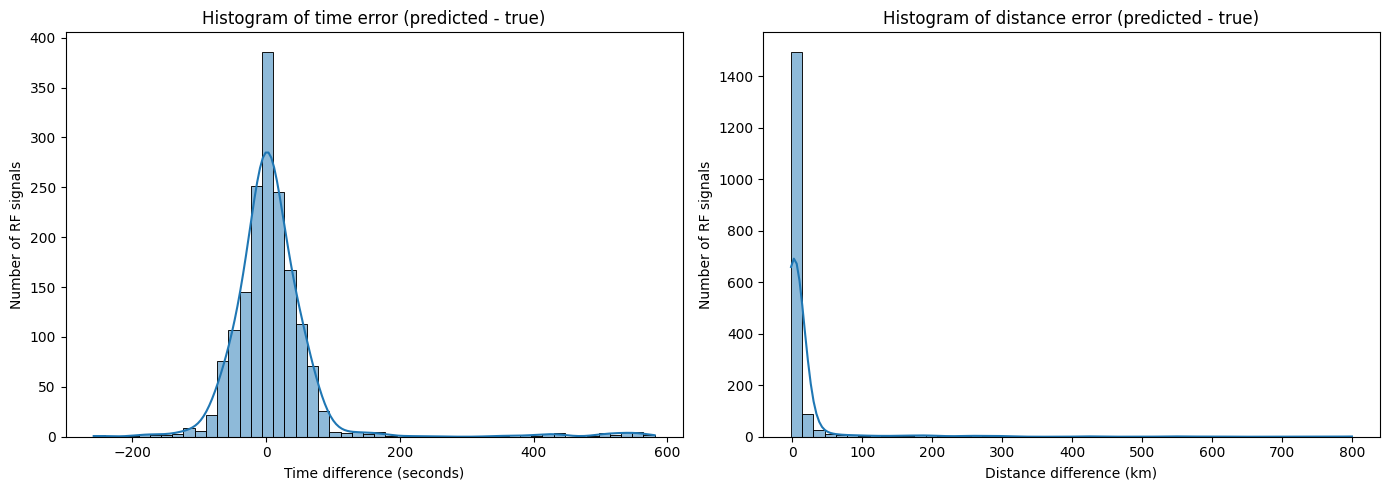

In [ ]:
# Calculate the prediction errors
df_exp_1_results["time_error"] = df_exp_1_results["time_diff_pred"] - df_exp_1_results["time_diff_true"]
df_exp_1_results["distance_error"] = df_exp_1_results["distance_diff_pred"] - df_exp_1_results["distance_diff_true"]

# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time difference error histogram
sns.histplot(df_exp_1_results["time_error"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Histogram of time error (predicted - true)")
axes[0].set_xlabel("Time difference (seconds)")
axes[0].set_ylabel("Number of RF signals")

# Distance difference error histogram
sns.histplot(df_exp_1_results["distance_error"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Histogram of distance error (predicted - true)")
axes[1].set_xlabel("Distance difference (km)")
axes[1].set_ylabel("Number of RF signals")

plt.tight_layout()
plt.show()

# Conclusion:
# For time differences: 
    # Most errors are within 2 minutes, but there are a few outliers where the predicted time is much later than the true time
# For distance difference:
    # There are no cases where the predicted distance is smaller than the true distance, 
    # However, there are some large errors where the predicted distance is much larger than the true distance
# Main question, what causes these extreme outliers and how can we prevent them? 

### __Experiment 2__

In [ ]:
# deze nog ff fixen

In [ ]:
# Conclusie experiment 1: 
# True match light dichterbij in tijd en afstand 
# Maar model kiest toch soms de verkeerde match 
# Dit kan meerdere redenen hebben, daarom testen we experiment 2

df_subset_stats = pd.read_pickle("../scripts/test_scripts/sample_statistics_5000.pkl")

df_exp_2 = make_dataframe(forward_results)[["RF_signal_id", "RF_track_id", "AIS_track_id_pred", "AIS_track_id_true"]]

# Calculate prediction stats
stats_pred = df_subset_stats.rename(columns={
    "ID": "AIS_track_id_pred",
    "mean_intra_time_diff": "mean_intra_time_diff_pred"
})

# Calculate true stats
stats_true = df_subset_stats.rename(columns={
    "ID": "AIS_track_id_true",
    "mean_intra_time_diff": "mean_intra_time_diff_true"
})

# Merge stats  
df_merged = df_exp_2.merge(
    stats_pred[["AIS_track_id_pred", "mean_intra_time_diff_pred"]],
    on="AIS_track_id_pred",
    how="left"
)
df_merged = df_merged.merge(
    stats_true[["AIS_track_id_true", "mean_intra_time_diff_true"]],
    on="AIS_track_id_true",
    how="left"
)

df_merged.head(5)

,RF_signal_id,RF_track_id,AIS_track_id_pred,AIS_track_id_true,mean_intra_time_diff_pred,mean_intra_time_diff_true
0,1,"(209087000, 10)","(351567000, 19)","(209087000, 10)",112.872321,134.707915
1,1,"(210499000, 15)","(368270390, 0)","(210499000, 15)",113.845719,197.706061
2,1,"(215228000, 7)","(636017316, 12)","(215228000, 7)",104.908547,127.058621
3,1,"(215765000, 2)","(636019582, 6)","(215765000, 2)",118.828723,110.529037
4,1,"(235010180, 19)","(477909100, 31)","(235010180, 19)",68.464789,85.723051


In [ ]:
# Als de samplingfrequentie van een verkeerde AIS-sequentie hoger is (dus mean_intra_time_diff lager) dan die van de juiste AIS-sequentie,
# dan is de kans groter dat het model die verkeerde sequentie kiest.

# Dus bijvoorbeeld:
    # AIS-track B (de foute, maar gekozen)
    # mean_intra_time_diff_pred = 60 seconden
    # AIS-track A (de juiste)
    # mean_intra_time_diff_true = 180 seconden
    
df_merged["mean_intra_time_diff_pred"].mean(), df_merged["mean_intra_time_diff_true"].mean()

(np.float64(109.99554201134245), np.float64(113.94780897504812))

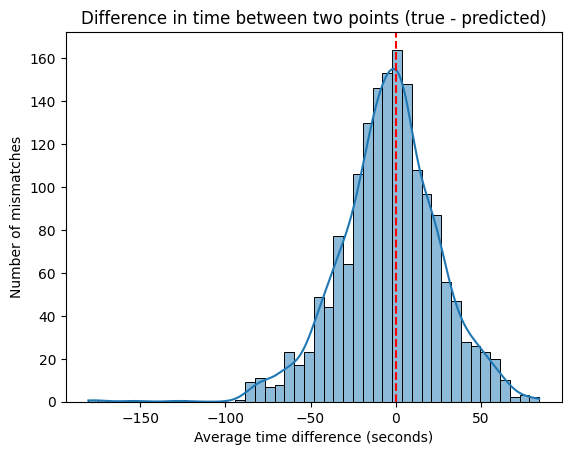

In [ ]:
df_merged["time_error"] = df_merged["mean_intra_time_diff_pred"] - df_merged["mean_intra_time_diff_true"]

sns.histplot(df_merged["time_error"], kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Difference in time between two points (true - predicted)")
plt.xlabel("Average time difference (seconds)")
plt.ylabel("Number of mismatches")
plt.show()

In [ ]:
# Plot is meer naar rechts geskewed, wat te verwachten was. Lijkt erop dat vooral de tail rechts ervoor zorgt dat
# er verkeerde matches worden gemaakt. Dit zijn de gevallen waarbij het tijdverschil tussen de punten van de pred veel lager is dan dat van de true match.

In [ ]:
df_correct_matches = forward_results[forward_results["is_true_match"] == True]

df_correct_matches = df_correct_matches.merge(
    df_subset_stats,
    left_on="AIS_track_id",
    right_on="ID",
    how="left"
) 

df_correct_matches["mean_intra_time_diff"].mean()

np.float64(102.82666589628856)

In [ ]:
# Dit verschil van goed gematchte tracks komt dicht in de buurt van "verkeerde" matches

### __Experiment 3__

In [ ]:
# a. Variantie van snelheid per track
track_stds = df_AIS.groupby("ID")["speed_kph"].agg(["std"]).reset_index()
track_stds.columns = ["ID", "std_speed_kph"]

# b. Stationair gedrag: aandeel tijd < 5 km/h
stationary_threshold = 5
df_AIS["is_stationary"] = df_AIS["speed_kph"] < stationary_threshold
stationary_ratio_per_track = (
    df_AIS.groupby("ID")["is_stationary"]
    .mean()
    .reset_index()
    .rename(columns={"is_stationary": "stationary_ratio"})
)

# Combineer alles in één lookup-table
track_behavior_stats = track_stds.merge(stationary_ratio_per_track, on="ID", how="left")
track_behavior_lookup = track_behavior_stats.set_index("ID")

In [ ]:
track_behavior_lookup

,std_speed_kph,stationary_ratio
ID,,
"(205717000, 3)",10.619726,0.320106
"(205717000, 7)",6.173660,0.643216
"(205717000, 82)",4.038880,0.004255
"(209017000, 19)",0.100799,0.000000
"(209017000, 23)",0.350731,0.000000
...,...,...
"(671960000, 144)",3.606904,0.063397
"(677059800, 2)",0.324018,0.000000
"(750000045, 1)",0.708410,0.000000


In [ ]:
def add_stats_info(row):
    AIS_true_id = row["RF_track_id"]
    AIS_pred_id = row["AIS_track_id"]
    is_true_match = row["is_true_match"]

    true_stats = track_behavior_lookup.loc[[AIS_true_id]] 

    if is_true_match:
        return pd.Series({
            "std_true": true_stats["std_speed_kph"].iloc[0],
            "stationary_ratio_true": true_stats["stationary_ratio"].iloc[0],
            "std_pred": None,
            "stationary_ratio_pred": None,
        })

    else:
        pred_stats = track_behavior_lookup.loc[[AIS_pred_id]]
        return pd.Series({
            "std_true": true_stats["std_speed_kph"].iloc[0],
            "stationary_ratio_true": true_stats["stationary_ratio"].iloc[0],
            "std_pred": pred_stats["std_speed_kph"].iloc[0],
            "stationary_ratio_pred": pred_stats["stationary_ratio"].iloc[0],
        })

In [ ]:
best_prediction_stats = best_predictions.copy()

best_prediction_stats[[
    "std_true", "stationary_ratio_true",
    "std_pred", "stationary_ratio_pred"
]] = best_prediction_stats.apply(add_stats_info, axis=1)

In [ ]:
best_prediction_stats[best_prediction_stats["is_true_match"] == True]


,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,std_true,stationary_ratio_true,std_pred,stationary_ratio_pred,std_error,stationary_ratio_error
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True,10.619726,0.320106,NaN,NaN,NaN,NaN
4,1,"(205717000, 7)","(205717000, 7)",-11.101144,-0.055785,True,6.173660,0.643216,NaN,NaN,NaN,NaN
6,1,"(205717000, 82)","(205717000, 82)",-24.772183,-0.035138,True,4.038880,0.004255,NaN,NaN,NaN,NaN
11,1,"(209017000, 19)","(209017000, 19)",-5.840272,-0.834325,True,0.100799,0.000000,NaN,NaN,NaN,NaN
12,1,"(209017000, 23)","(209017000, 23)",-6.291301,-0.190645,True,0.350731,0.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18556,41,"(366904890, 0)","(366904890, 0)",-176.864184,-0.026688,True,7.326846,0.128867,NaN,NaN,NaN,NaN
19864,41,"(366938770, 0)","(366938770, 0)",-148.204531,-0.026728,True,9.416051,0.245086,NaN,NaN,NaN,NaN
20025,41,"(366938780, 0)","(366938780, 0)",-192.577800,-0.026625,True,10.174818,0.287571,NaN,NaN,NaN,NaN
20868,41,"(367121010, 0)","(367121010, 0)",-186.983258,-0.026496,True,7.267271,0.147513,NaN,NaN,NaN,NaN


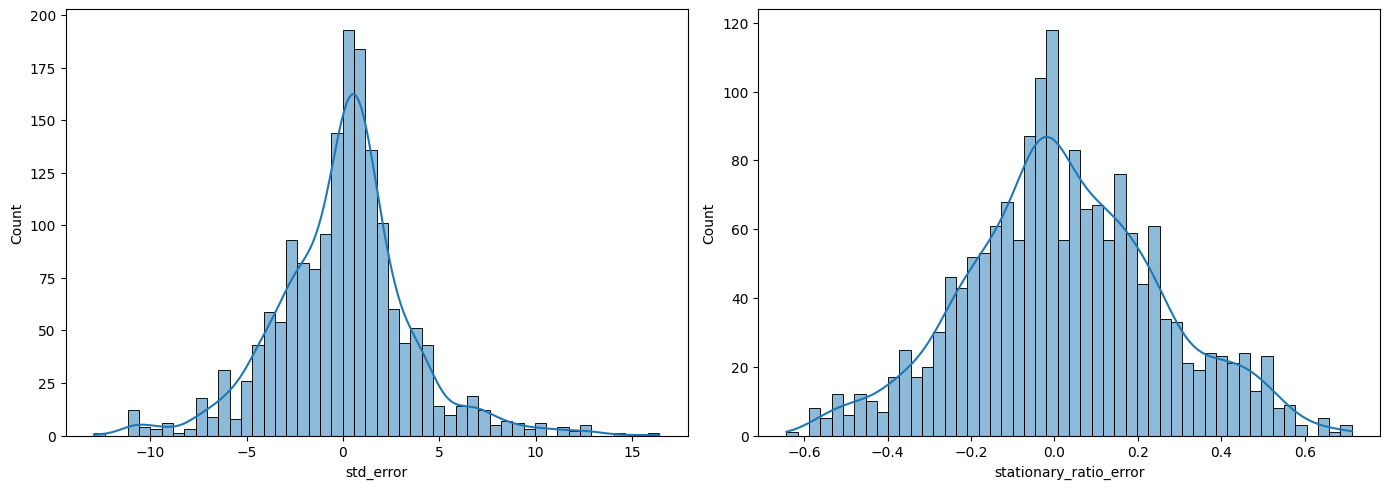

In [ ]:
kars = best_prediction_stats[best_prediction_stats["is_true_match"] == False].copy()

# Calculate the prediction errors
kars["std_error"] = kars["std_pred"] - kars["std_true"]
kars["stationary_ratio_error"] = kars["stationary_ratio_pred"] - kars["stationary_ratio_true"]

# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time difference error histogram
sns.histplot(kars["std_error"], bins=50, kde=True, ax=axes[0])
# axes[0].set_title("Histogram of time error (predicted - true)")
# axes[0].set_xlabel("Time difference (seconds)")
# axes[0].set_ylabel("Number of RF signals")

# Distance difference error histogram
sns.histplot(kars["stationary_ratio_error"], bins=50, kde=True, ax=axes[1])
# axes[1].set_title("Histogram of distance error (predicted - true)")
# axes[1].set_xlabel("Distance difference (km)")
# axes[1].set_ylabel("Number of RF signals")

plt.tight_layout()
plt.show()

In [ ]:
kars.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,std_true,stationary_ratio_true,std_pred,stationary_ratio_pred,std_error,stationary_ratio_error
16,1,"(209087000, 10)","(351567000, 19)",-33.793927,-0.031465,False,13.760366,0.567929,11.156295,0.403166,-2.604072,-0.164763
809,1,"(210499000, 15)","(368270390, 0)",-129.616274,-0.029272,False,7.141008,0.450832,4.471183,0.377145,-2.669826,-0.073687
1217,1,"(215228000, 7)","(636017316, 12)",-36.448784,-0.031126,False,10.006597,0.463918,7.905039,0.345004,-2.101559,-0.118913
1443,1,"(215765000, 2)","(636019582, 6)",-49.652530,-0.029207,False,11.262795,0.348967,11.635834,0.458235,0.373039,0.109269
2383,1,"(235010180, 19)","(477909100, 31)",-27.748794,-0.035484,False,9.646643,0.147351,4.210870,0.000000,-5.435774,-0.147351


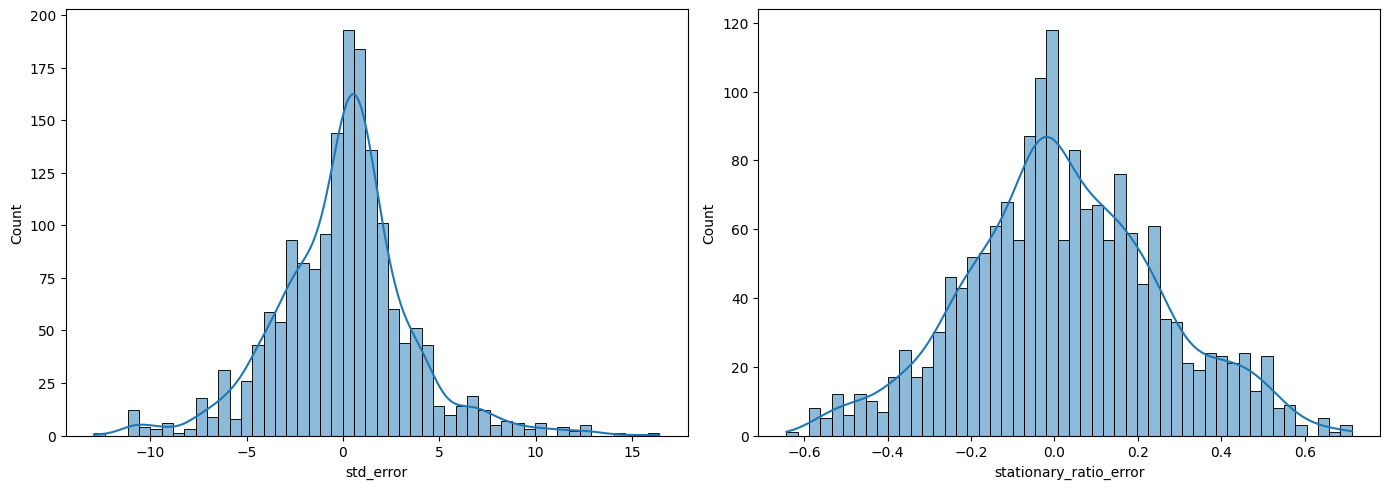

In [ ]:
# Calculate the prediction errors
best_prediction_stats["std_error"] = best_prediction_stats["std_pred"] - best_prediction_stats["std_true"]
best_prediction_stats["stationary_ratio_error"] = best_prediction_stats["stationary_ratio_pred"] - best_prediction_stats["stationary_ratio_true"]

# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time difference error histogram
sns.histplot(best_prediction_stats["std_error"], bins=50, kde=True, ax=axes[0])
# axes[0].set_title("Histogram of time error (predicted - true)")
# axes[0].set_xlabel("Time difference (seconds)")
# axes[0].set_ylabel("Number of RF signals")

# Distance difference error histogram
sns.histplot(best_prediction_stats["stationary_ratio_error"], bins=50, kde=True, ax=axes[1])
# axes[1].set_title("Histogram of distance error (predicted - true)")
# axes[1].set_xlabel("Distance difference (km)")
# axes[1].set_ylabel("Number of RF signals")

plt.tight_layout()
plt.show()

In [ ]:
row_count_per_id = df_AIS.groupby("ID").size().reset_index(name="row_count")
row_count_per_id = row_count_per_id.set_index("ID")

def row_counts(row):
    AIS_true_id = row["RF_track_id"]
    AIS_pred_id = row["AIS_track_id"]
    is_true_match = row["is_true_match"]

    true_count = row_count_per_id.loc[[AIS_true_id]] 

    if is_true_match:
        return pd.Series({
            "#_of_rows_true": true_count["row_count"].iloc[0],
            "#_of_rows_pred": None
        })

    else:
        pred_count = row_count_per_id.loc[[AIS_pred_id]]
        return pd.Series({
            "#_of_rows_true": true_count["row_count"].iloc[0],
            "#_of_rows_pred": pred_count["row_count"].iloc[0]
        })
        
counts = best_predictions.copy()

counts[[
    "#_of_rows_true", "#_of_rows_pred"]] = counts.apply(row_counts, axis=1)

counts

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,normalized_forward_score_alpha,ID,count,#_of_rows_true,#_of_rows_pred
0,1,"(205717000, 3)","(205717000, 3)",-15.906163,-0.042080,True,-0.076177,"(205717000, 3)",378,378.0,NaN
4,1,"(205717000, 7)","(205717000, 7)",-11.115426,-0.055856,True,-0.094833,"(205717000, 7)",199,199.0,NaN
6,1,"(205717000, 82)","(205717000, 82)",-24.751147,-0.035108,True,-0.067643,"(205717000, 82)",705,705.0,NaN
11,1,"(209017000, 19)","(209017000, 19)",-5.838397,-0.834057,True,-1.013224,"(209017000, 19)",7,7.0,NaN
12,1,"(209017000, 23)","(209017000, 23)",-6.235568,-0.188957,True,-0.268049,"(209017000, 23)",33,33.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
19117,41,"(366904890, 0)","(366904890, 0)",-176.378774,-0.026615,True,-0.064160,"(366904890, 0)",6627,6627.0,NaN
20441,41,"(366938770, 0)","(366938770, 0)",-148.232392,-0.026733,True,-0.063304,"(366938770, 0)",5545,5545.0,NaN
20615,41,"(366938780, 0)","(366938780, 0)",-192.511706,-0.026616,True,-0.064725,"(366938780, 0)",7233,7233.0,NaN
21475,41,"(367121010, 0)","(367121010, 0)",-186.992960,-0.026498,True,-0.064279,"(367121010, 0)",7057,7057.0,NaN


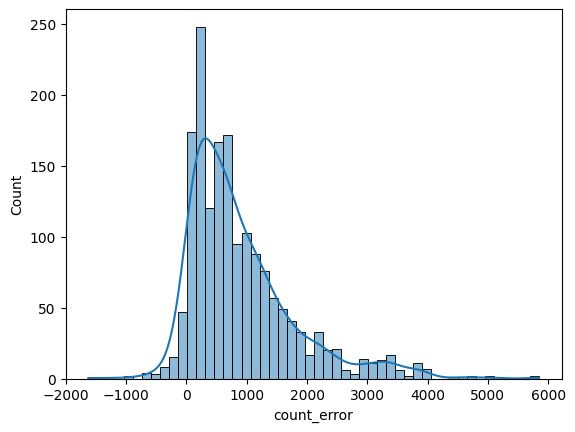

In [ ]:
# Calculate the prediction errors
counts["count_error"] = counts["#_of_rows_pred"] - counts["#_of_rows_true"]

# Time difference error histogram
sns.histplot(counts["count_error"], bins=50, kde=True)
# axes[0].set_title("Histogram of time error (predicted - true)")
# axes[0].set_xlabel("Time difference (seconds)")
# axes[0].set_ylabel("Number of RF signals")
plt.show()

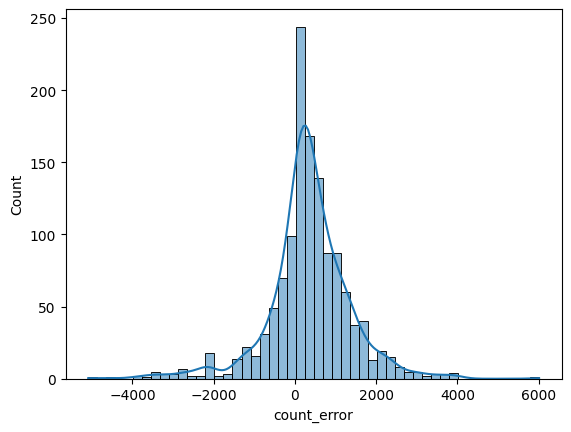

In [ ]:
# Calculate the prediction errors
counts["count_error"] = counts["#_of_rows_pred"] - counts["#_of_rows_true"]

# Time difference error histogram
sns.histplot(counts["count_error"], bins=50, kde=True)
# axes[0].set_title("Histogram of time error (predicted - true)")
# axes[0].set_xlabel("Time difference (seconds)")
# axes[0].set_ylabel("Number of RF signals")
plt.show()

In [ ]:
counts

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,#_of_rows_true,#_of_rows_pred,count_error
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True,378.0,NaN,NaN
4,1,"(205717000, 7)","(205717000, 7)",-11.101144,-0.055785,True,199.0,NaN,NaN
6,1,"(205717000, 82)","(205717000, 82)",-24.772183,-0.035138,True,705.0,NaN,NaN
11,1,"(209017000, 19)","(209017000, 19)",-5.840272,-0.834325,True,7.0,NaN,NaN
12,1,"(209017000, 23)","(209017000, 23)",-6.291301,-0.190645,True,33.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
18556,41,"(366904890, 0)","(366904890, 0)",-176.864184,-0.026688,True,6627.0,NaN,NaN
19864,41,"(366938770, 0)","(366938770, 0)",-148.204531,-0.026728,True,5545.0,NaN,NaN
20025,41,"(366938780, 0)","(366938780, 0)",-192.577800,-0.026625,True,7233.0,NaN,NaN
20868,41,"(367121010, 0)","(367121010, 0)",-186.983258,-0.026496,True,7057.0,NaN,NaN


/var/folders/0_/g2mh2dg54095rw5w9f735rg80000gn/T/ipykernel_71721/2698862416.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


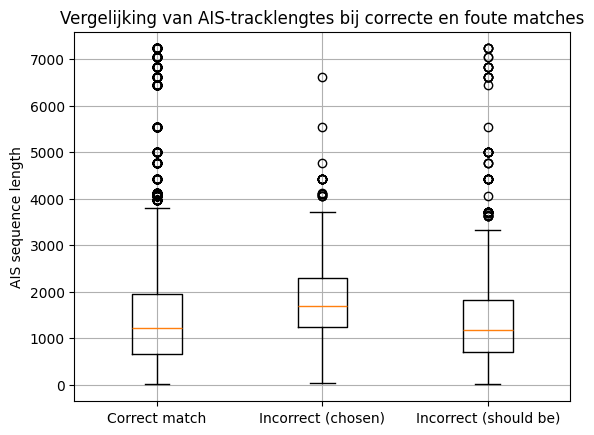

In [ ]:
# Maak Series op basis van match status
correct_lengths = counts[counts["is_true_match"]]["#_of_rows_true"]
incorrect_chosen_lengths = counts[~counts["is_true_match"]]["#_of_rows_pred"]
incorrect_true_lengths = counts[~counts["is_true_match"]]["#_of_rows_true"]
plt.boxplot(
    [correct_lengths, incorrect_chosen_lengths, incorrect_true_lengths],
    labels=["Correct match", "Incorrect (chosen)", "Incorrect (should be)"]
)
plt.ylabel("AIS sequence length")
plt.title("Vergelijking van AIS-tracklengtes bij correcte en foute matches")
plt.grid(True)
plt.show()

In [ ]:
df_merged["time_error"] = df_merged["mean_intra_time_diff_pred"] - df_merged["mean_intra_time_diff_true"]

sns.histplot(df_merged["time_error"], kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Difference in time between two points (true - predicted)")
plt.xlabel("Average time difference (seconds)")
plt.ylabel("Number of mismatches")
plt.show()

In [ ]:
row_count_per_id = df_AIS.groupby("ID").size().reset_index(name="row_count")
row_count_per_id

,ID,row_count
0,"(205717000, 3)",378
1,"(205717000, 7)",199
2,"(205717000, 82)",705
3,"(209017000, 19)",7
4,"(209017000, 23)",33
...,...,...
4995,"(671960000, 144)",836
4996,"(677059800, 2)",5
4997,"(750000045, 1)",1072
4998,"(750000045, 10)",7


### __Experiment 4__

In [ ]:
def compute_avg_speed_per_match(df, df_AIS):
    avg_speeds = []

    for _, row in df.iterrows():
        AIS_id = row["AIS_track_id"]
        ais_data = df_AIS[df_AIS["ID"] == AIS_id]
        
        speed = ais_data["speed_kph"].mean()
        avg_speeds.append(speed)

    df["avg_speed_kph"] = avg_speeds
    return df

In [ ]:
df_speed = compute_avg_speed_per_match(best_predictions, df_AIS)

# Gemiddelde snelheid per groep
mean_correct = df_speed[df_speed["is_true_match"]]["avg_speed_kph"].mean()
mean_wrong = df_speed[~df_speed["is_true_match"]]["avg_speed_kph"].mean()

print(f"✅ Correcte matches – gemiddelde snelheid: {mean_correct:.2f} km/h")
print(f"❌ Foute matches – gemiddelde snelheid:   {mean_wrong:.2f} km/h")

✅ Correcte matches – gemiddelde snelheid: 14.48 km/h
❌ Foute matches – gemiddelde snelheid:   11.86 km/h


In [ ]:
best_predictions[best_predictions["is_true_match"] == False]

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,heading_diff,avg_speed_kph
16,1,"(209087000, 10)","(351567000, 19)",-33.793927,-0.031465,False,176.349396,12.515512
809,1,"(210499000, 15)","(368270390, 0)",-129.616274,-0.029272,False,24.173921,5.248442
1217,1,"(215228000, 7)","(636017316, 12)",-36.448784,-0.031126,False,1.537590,10.822767
1443,1,"(215765000, 2)","(636019582, 6)",-49.652530,-0.029207,False,12.978864,11.801322
2383,1,"(235010180, 19)","(477909100, 31)",-27.748794,-0.035484,False,4.278719,21.424220
...,...,...,...,...,...,...,...,...
41776,24,"(636022464, 30)","(256524000, 97)",-70.498425,-0.028053,False,169.914669,13.275752
33792,25,"(538009326, 1)","(477950300, 3)",-61.712304,-0.028744,False,31.419968,13.989498
41785,25,"(636022464, 30)","(256524000, 97)",-70.228260,-0.027946,False,171.218169,13.275752
43546,31,"(636093060, 4)","(368270390, 0)",-121.433221,-0.027424,False,12.440078,5.248442


In [ ]:
# Groepeer df_AIS per track (ID = (MMSI, TrackID)) en bereken gemiddelde snelheid
avg_speeds = df_AIS.groupby("ID")["speed_kph"].mean()

# Nu kun je voor elk RF_track_id in jouw matching-resultaten de snelheid ophalen:
def get_avg_speed(row):
    rf_id = row["RF_track_id"]
    return avg_speeds.get(rf_id, None)  # retourneert None als ID niet bestaat

# Pas dit toe op je resultaten DataFrame
df_test = best_predictions[best_predictions["is_true_match"] == False]
df_test["avg_speed_kph"] = df_test.apply(get_avg_speed, axis=1)
df_test["avg_speed_kph"].mean()

/var/folders/0_/g2mh2dg54095rw5w9f735rg80000gn/T/ipykernel_30369/327113182.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test["avg_speed_kph"] = df_test.apply(get_avg_speed, axis=1)


np.float64(12.65609186227581)

In [ ]:
avg_speeds.get((209087000, 10)	, None)

np.float64(11.256221190819995)

In [ ]:
best_predictions

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,heading_diff,avg_speed_kph
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True,1.783668,14.688600
4,1,"(205717000, 7)","(205717000, 7)",-11.101144,-0.055785,True,6.735332,5.200190
6,1,"(205717000, 82)","(205717000, 82)",-24.772183,-0.035138,True,3.719302,18.169722
11,1,"(209017000, 19)","(209017000, 19)",-5.840272,-0.834325,True,162.318214,21.643202
12,1,"(209017000, 23)","(209017000, 23)",-6.291301,-0.190645,True,7.071329,20.864823
...,...,...,...,...,...,...,...,...
18556,41,"(366904890, 0)","(366904890, 0)",-176.864184,-0.026688,True,169.228342,17.742335
19864,41,"(366938770, 0)","(366938770, 0)",-148.204531,-0.026728,True,14.384131,15.919329
20025,41,"(366938780, 0)","(366938780, 0)",-192.577800,-0.026625,True,173.596608,15.523057
20868,41,"(367121010, 0)","(367121010, 0)",-186.983258,-0.026496,True,166.259672,16.328156


In [ ]:
# bereken de gemiddelde snelheid voor foute matches en dan met true 

,RF_signal_id,RF_track_id,AIS_track_id,forward_score,normalized_forward_score,is_true_match,heading_diff,avg_speed_kph
0,1,"(205717000, 3)","(205717000, 3)",-16.953044,-0.044849,True,1.783668,14.688600
4,1,"(205717000, 7)","(205717000, 7)",-11.101144,-0.055785,True,6.735332,5.200190
6,1,"(205717000, 82)","(205717000, 82)",-24.772183,-0.035138,True,3.719302,18.169722
11,1,"(209017000, 19)","(209017000, 19)",-5.840272,-0.834325,True,162.318214,21.643202
12,1,"(209017000, 23)","(209017000, 23)",-6.291301,-0.190645,True,7.071329,20.864823
...,...,...,...,...,...,...,...,...
18556,41,"(366904890, 0)","(366904890, 0)",-176.864184,-0.026688,True,169.228342,17.742335
19864,41,"(366938770, 0)","(366938770, 0)",-148.204531,-0.026728,True,14.384131,15.919329
20025,41,"(366938780, 0)","(366938780, 0)",-192.577800,-0.026625,True,173.596608,15.523057
20868,41,"(367121010, 0)","(367121010, 0)",-186.983258,-0.026496,True,166.259672,16.328156


In [ ]:
df_AIS


,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id,is_stationary
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3,False
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3,False
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3,False
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3,False
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4356540,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:53:58,16.45977,-66.45095,7.6,141.0,348.0,1.247281,12.902906,16,False
4356541,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:55:59,16.45758,-66.44760,6.7,138.0,121.0,0.432344,12.863116,16,False
4356542,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:58:19,16.45501,-66.44370,7.0,138.0,140.0,0.504614,12.975783,16,False
4356543,"(750000045, 16)",750000045,IMO6702284,2024-01-10 23:02:55,16.44986,-66.43640,6.4,139.0,276.0,0.966425,12.605543,16,False


In [ ]:
import math
noise = np.random.uniform(-60, 60)
bearing = (93.0 + noise) % 360
bearing

60.18041701897933

### __Plot routes of mismatch__


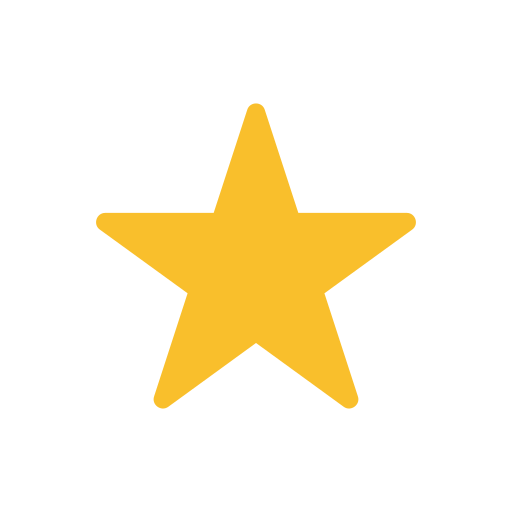
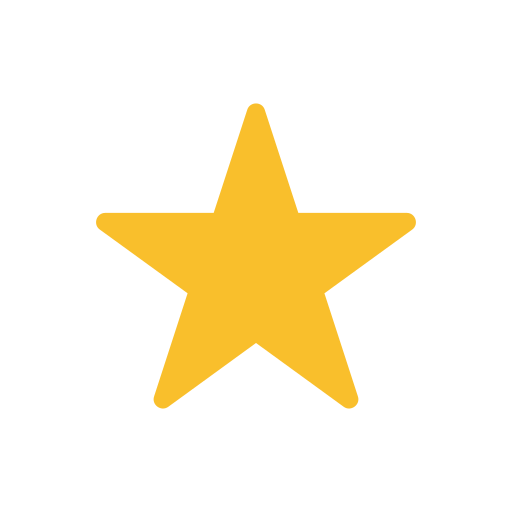
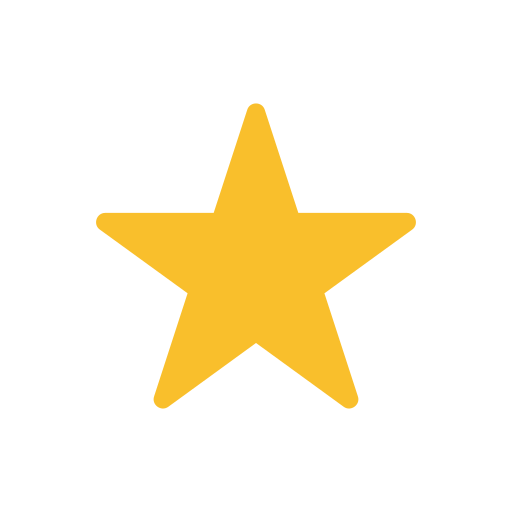
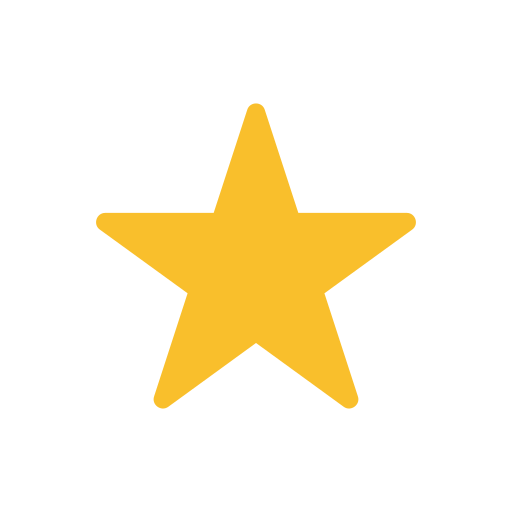
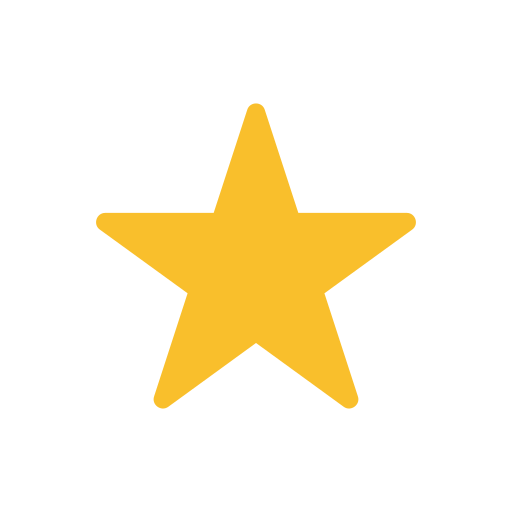
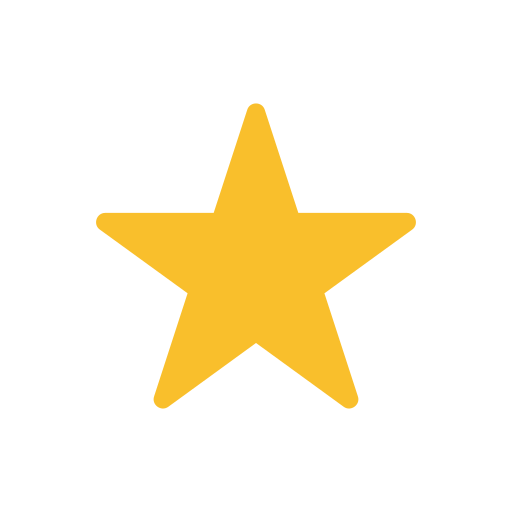
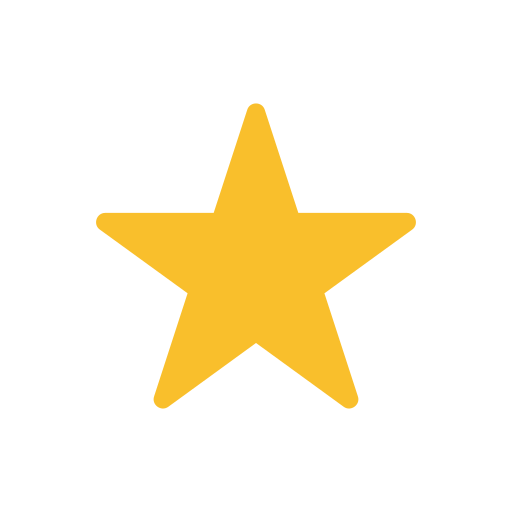
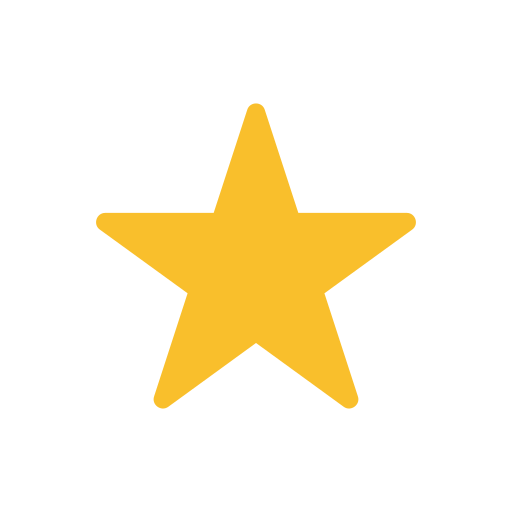
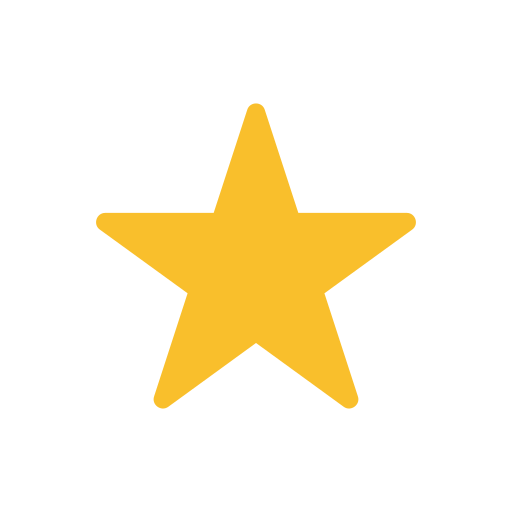
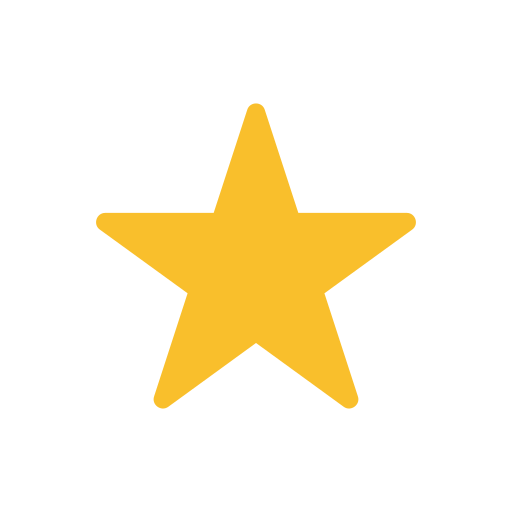
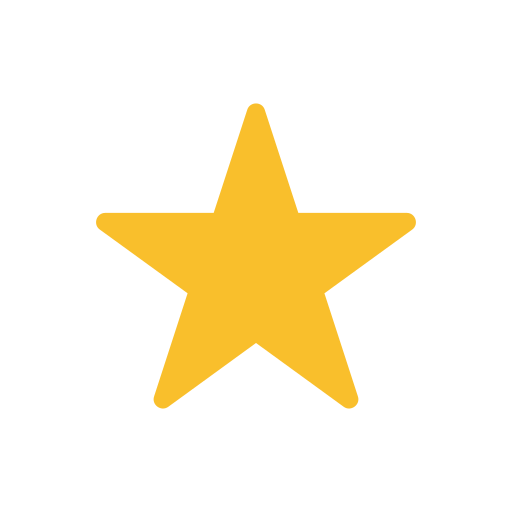
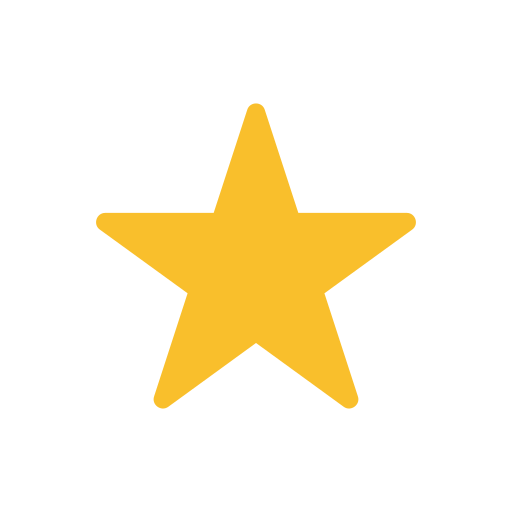
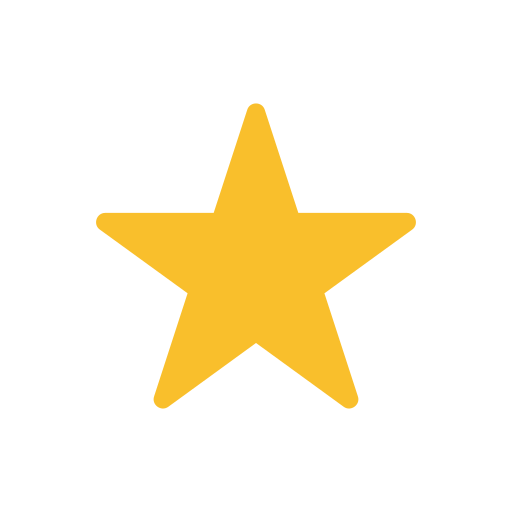
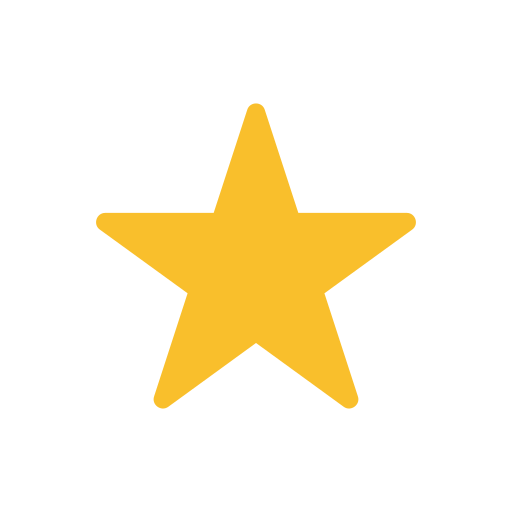
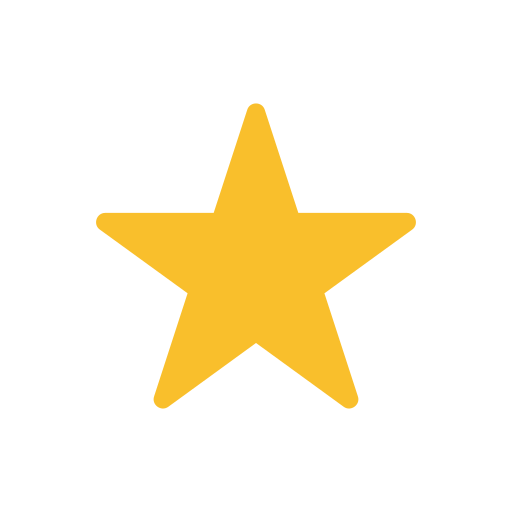
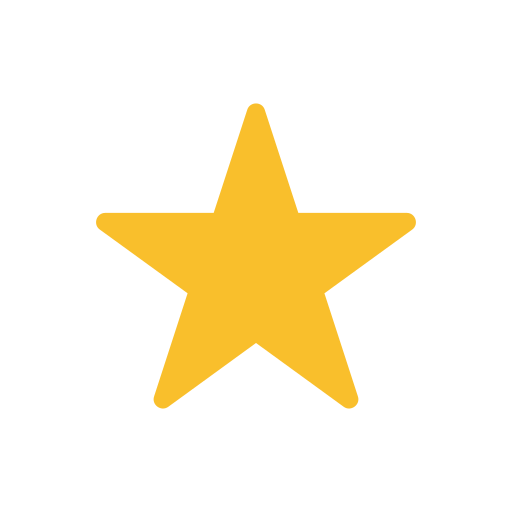
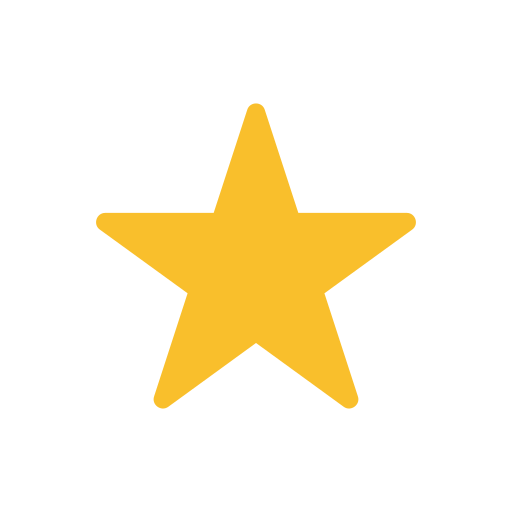
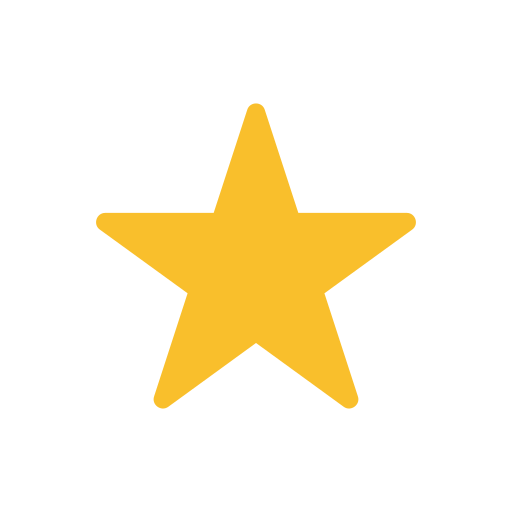

In [ ]:
# geef de sterren een ander kleurtje 

df_train_set = pd.read_pickle("../scripts/test_scripts/train_data_5000_samples.pkl") 
df_AIS = pd.read_pickle("../scripts/test_scripts/AIS_5000_sample_no_RF.pkl") 

plot_AIS_and_RF_data(df_AIS, df_train_set, [(209087000, 10), (351567000, 19)])

In [ ]:
df_AIS

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id,is_stationary
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3,False
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3,False
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3,False
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3,False
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4356540,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:53:58,16.45977,-66.45095,7.6,141.0,348.0,1.247281,12.902906,16,False
4356541,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:55:59,16.45758,-66.44760,6.7,138.0,121.0,0.432344,12.863116,16,False
4356542,"(750000045, 16)",750000045,IMO6702284,2024-01-10 22:58:19,16.45501,-66.44370,7.0,138.0,140.0,0.504614,12.975783,16,False
4356543,"(750000045, 16)",750000045,IMO6702284,2024-01-10 23:02:55,16.44986,-66.43640,6.4,139.0,276.0,0.966425,12.605543,16,False
